# Overall Analysis of ABFE Rescoring

In [1]:
import os
import glob
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from rdkit import Chem
from rdkit.Chem import rdMolAlign, AllChem
import spyrmsd.molecule
import spyrmsd.rmsd

# Set up plotting style
plt.style.use('ggplot')
%matplotlib inline

## 1. Configuration

Define paths and parameters for the analysis.

In [2]:
# Define base directories
BASE_DIR = Path(".").absolute() 
ABFE_DIR = BASE_DIR / "abfe"  # ABFE results are in parent directory
REFERENCE_SDF = BASE_DIR / "input/test_mers.sdf"
FEGROW_RESULT_DIR = BASE_DIR / "../input/fegrow_result"  # Original SDF files

# Parameters
RMSD_THRESHOLD = 2.0  # Angstroms -- threshold below which we consider a pose to be close to the reference.

# --- Processed-data cache -------------------------------------------------------
PROCESSED_CACHE = BASE_DIR / "analysis_results" / "abfe_df_processed.csv"
FORCE_REBUILD = False

# Whether the raw input trees are present. Cells that produce per-structure artefacts
# (3D overlays / PDB exports) need the raw files and are skipped when absent;
# the dataframe-level analysis runs entirely from the cache.
RAW_DATA_AVAILABLE = ABFE_DIR.exists() and FEGROW_RESULT_DIR.exists()
print(f"Raw ABFE/fegrow data available: {RAW_DATA_AVAILABLE}")
print(f"Processed-data cache: {PROCESSED_CACHE} (exists: {PROCESSED_CACHE.exists()})")

Raw ABFE/fegrow data available: False
Processed-data cache: /home/campus.ncl.ac.uk/nfc78/research/polaris_retrospective/polaris_plots/analysis_results/abfe_df_processed.csv (exists: True)


### Rerunning without the raw data

The expensive steps (collecting `overall_stats.dat`, computing pose RMSDs, and computing equilibrated-pose RMSDs from the AMBER systems) write the fully-processed per-(molecule, receptor) dataframe to `PROCESSED_CACHE` (`analysis_results/abfe_df_processed.csv`). On any later run that cache is loaded in preference to re-reading the raw `abfe/`, fegrow SDF and AMBER files, so the entire dataframe-level analysis (success rates, CDFs, plots) reproduces from the CSV alone.

Cells that build per-structure 3D artefacts (superimposed SDFs in section 5.1, the `visualise()` helper, and the pose-PDB export in section 14) genuinely require the raw coordinates and cannot be reconstructed from the dataframe; they skip themselves with a message when the raw data is absent.

Set `FORCE_REBUILD = True` (or delete the cache file) to rebuild from the raw data.

## 2. Parse ABFE Results

Read all `overall_stats.dat` files and extract mean free energies. Note that runs for charged molecules will have failed on set-up and are ignored. There were a few other failures due to cluster issues.

In [3]:
def parse_overall_stats(filepath: str) -> dict:
    """
    Parse overall_stats.dat file to extract mean free energy.

    Parameters:
    -----------
    filepath : str
        Path to overall_stats.dat file

    Returns:
    --------
    dict : Dictionary with 'mean_dg' and 'error' keys.

    Raises:
    -------
    FileNotFoundError
        If the file does not exist.
    ValueError
        If the expected mean free energy line is missing.
    """
    filepath = Path(filepath)
    if not filepath.exists():
        raise FileNotFoundError(f"overall_stats.dat not found: {filepath}")

    with open(filepath, 'r') as f:
        content = f.read()

    # Format: "Mean free energy: -14.020 + /- 2.899 kcal/mol"
    match = re.search(r'Mean free energy:\s*([-\d.]+)\s*\+\s*/\-\s*([-\d.]+)', content)
    if not match:
        raise ValueError(f"Could not parse mean free energy from: {filepath}")

    return {
        'mean_dg': float(match.group(1)),
        'error': float(match.group(2))
    }

# Test the function (only if the raw file is present)
test_file = BASE_DIR / "abfe/mol3/rec_final_1/output/overall_stats.dat"
if test_file.exists():
    result = parse_overall_stats(test_file)
    print(f"Test parse result: {result}")
else:
    print(f"Skipping parse test ({test_file} not present); cached results will be used.")

Skipping parse test (/home/campus.ncl.ac.uk/nfc78/research/polaris_retrospective/polaris_plots/abfe/mol3/rec_final_1/output/overall_stats.dat not present); cached results will be used.


In [4]:
def collect_abfe_results(abfe_dir: str, fegrow_dir: str) -> pd.DataFrame:
    """
    Collect all ABFE results from directory structure.

    Parameters:
    -----------
    abfe_dir : str
        Base directory containing mol*/rec_final_* subdirectories
    fegrow_dir : str
        Directory containing original SDF files from fegrow

    Returns:
    --------
    pd.DataFrame : DataFrame with columns [mol_id, receptor_id, mean_dg, error, stats_path, ligand_sdf_path]

    Raises:
    -------
    ValueError
        If any expected mapping/parsing step fails.
    """
    results = []
    
    abfe_dir = Path(abfe_dir)
    fegrow_dir = Path(fegrow_dir)

    # Pattern: abfe/mol*/rec_final_*/output/overall_stats.dat
    stats_pattern = str(abfe_dir / "mol*/rec_final_*/output/overall_stats.dat")
    stats_files = glob.glob(stats_pattern)

    if not stats_files:
        raise ValueError(f"No overall_stats.dat files found for pattern: {stats_pattern}")

    print(f"Found {len(stats_files)} overall_stats.dat files")

    for stats_file in sorted(stats_files):
        stats_file_path = Path(stats_file)
        parts = stats_file_path.parts

        mol_id = None
        receptor_id = None
        mol_idx = None
        rec_idx = None
        for i, part in enumerate(parts):
            if part.startswith('mol'):
                mol_id = part
                mol_idx = i
            if part.startswith('rec_final_'):
                receptor_id = part
                rec_idx = i

        if mol_id is None or receptor_id is None:
            raise ValueError(f"Could not extract mol/rec from {stats_file}")

        stats = parse_overall_stats(stats_file)

        mol_dir = Path(*parts[:mol_idx + 1])
        rec_dir = Path(*parts[:rec_idx + 1])

        csv_path = mol_dir / "mol_scores_sorted.csv"
        if not csv_path.exists():
            raise FileNotFoundError(f"Missing mol_scores_sorted.csv: {csv_path}")

        mol_csv = pd.read_csv(csv_path)
        for required_col in ("receptor", "ligand"):
            if required_col not in mol_csv.columns:
                raise ValueError(f"Missing column '{required_col}' in {csv_path}")

        rec_num = receptor_id.replace('rec_final_', '')
        expected_receptor_name = f"rec_final_{rec_num}.pdb"
        matching_rows = mol_csv[mol_csv['receptor'].astype(str) == expected_receptor_name]

        if len(matching_rows) != 1:
            raise ValueError(
                f"Expected exactly 1 row for receptor '{expected_receptor_name}' in {csv_path}, found {len(matching_rows)}"
            )

        ligand_filename = matching_rows.iloc[0]['ligand']
        if pd.isna(ligand_filename) or not str(ligand_filename).strip():
            raise ValueError(f"Empty ligand filename for {mol_id}/{receptor_id} in {csv_path}")

        ligand_sdf_path = fegrow_dir / str(ligand_filename)
        if not ligand_sdf_path.exists():
            raise FileNotFoundError(f"SDF file not found: {ligand_sdf_path}")

        results.append({
            'mol_id': mol_id,
            'receptor_id': receptor_id,
            'mean_dg': stats['mean_dg'],
            'error': stats['error'],
            'stats_path': str(stats_file),
            'ligand_sdf_path': str(ligand_sdf_path),
            'mol_dir': str(mol_dir),
            'rec_dir': str(rec_dir)
        })

    df = pd.DataFrame(results)
    if df.empty:
        raise ValueError("No ABFE results were collected")

    df = df.sort_values(['mol_id', 'mean_dg']).reset_index(drop=True)
    return df

# Load the fully-processed dataframe from cache if present (so the notebook can be
# rerun without the raw ABFE files); otherwise collect from the raw directory tree.
if not FORCE_REBUILD and PROCESSED_CACHE.exists():
    abfe_df = pd.read_csv(PROCESSED_CACHE)
    print(f"Loaded cached processed dataframe from {PROCESSED_CACHE}")
    print(f"  {len(abfe_df)} rows; columns: {list(abfe_df.columns)}")
else:
    abfe_df = collect_abfe_results(ABFE_DIR, FEGROW_RESULT_DIR)
    print(f"\nCollected {len(abfe_df)} ABFE calculations from raw files")
    print(f"Unique molecules: {abfe_df['mol_id'].nunique()}")
    print(f"Unique receptors: {abfe_df['receptor_id'].nunique()}")
    print(f"SDF files found: {abfe_df['ligand_sdf_path'].notna().sum()}/{len(abfe_df)}")
abfe_df

Loaded cached processed dataframe from /home/campus.ncl.ac.uk/nfc78/research/polaris_retrospective/polaris_plots/analysis_results/abfe_df_processed.csv
  401 rows; columns: ['mol_id', 'receptor_id', 'mean_dg', 'error', 'stats_path', 'ligand_sdf_path', 'mol_dir', 'rec_dir', 'rmsd', 'mean_dg_normalized', 'equil_rmsd_heavy', 'equil_ref_rmsd', 'equil_reason']


,mol_id,receptor_id,mean_dg,error,stats_path,ligand_sdf_path,mol_dir,rec_dir,rmsd,mean_dg_normalized,equil_rmsd_heavy,equil_ref_rmsd,equil_reason
0,mol11,rec_final_9,-15.965,1.909,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,3.436622,-5.023600,1.960371,4.377478,NaN
1,mol11,rec_final_20,-15.013,3.051,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,4.121978,-4.071600,1.691425,3.898685,NaN
2,mol11,rec_final_19,-14.350,0.983,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,3.436383,-3.408600,2.010125,3.541162,NaN
3,mol11,rec_final_16,-13.948,0.992,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,3.436613,-3.006600,1.564896,3.639764,NaN
4,mol11,rec_final_13,-13.370,2.424,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,3.434843,-2.428600,1.017730,3.728062,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
396,mol9,rec_final_7,-15.170,4.732,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,2.993236,1.954357,2.895704,2.536529,NaN
397,mol9,rec_final_5,-14.872,3.419,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,0.727450,2.252357,2.650417,2.756205,NaN
398,mol9,rec_final_18,-14.150,4.512,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,6.656068,2.974357,2.290835,7.609581,NaN
399,mol9,rec_final_15,-13.642,3.177,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,0.738464,3.482357,1.462865,1.301732,NaN


In [5]:
# Print all mol IDs in numeric order (convert to int for sorting)
for mol_id in sorted(abfe_df['mol_id'].unique(), key=lambda x: int(x.replace('mol', ''))):
    print(mol_id)

mol3
mol4
mol7
mol9
mol11
mol12
mol13
mol16
mol17
mol18
mol20
mol21
mol22
mol25
mol26
mol27
mol30
mol33
mol34
mol35
mol36
mol37
mol39
mol40
mol43
mol44
mol45


## 3. Load Reference Structures

Read the true ligand poses from `input/test_mers.sdf`. Each molecule in the SDF will be indexed sequentially.

In [6]:
def load_reference_structures(sdf_path: str) -> dict:
    """
    Load reference structures from SDF file.
    
    Parameters:
    -----------
    sdf_path : str
        Path to reference SDF file
        
    Returns:
    --------
    dict : Dictionary mapping mol_id (e.g., 'mol3', 'mol4') to RDKit molecule objects
    """
    suppl = Chem.SDMolSupplier(sdf_path, removeHs=False)
    references = {}
    
    for idx, mol in enumerate(suppl):
        if mol is not None:
            mol_id = f"mol{idx}"  # Assuming numbering starts at mol3
            references[mol_id] = mol
    
    print(f"Loaded {len(references)} reference structures")
    print(f"Molecule IDs: {sorted(references.keys())}")
    
    return references

# Load reference structures (needed only when (re)computing RMSDs from raw data;
# on a cache-only rerun the RMSDs are already stored in abfe_df).
if REFERENCE_SDF.exists():
    reference_mols = load_reference_structures(str(REFERENCE_SDF))
    for mol_id in sorted(list(reference_mols.keys())[:5]):
        mol = reference_mols[mol_id]
        print(f"{mol_id}: {mol.GetNumAtoms()} atoms")
else:
    reference_mols = {}
    print(f"Reference SDF not found at {REFERENCE_SDF}; running in cache-only mode "
          f"(RMSDs are read from {PROCESSED_CACHE}).")

Reference SDF not found at /home/campus.ncl.ac.uk/nfc78/research/polaris_retrospective/polaris_plots/input/test_mers.sdf; running in cache-only mode (RMSDs are read from /home/campus.ncl.ac.uk/nfc78/research/polaris_retrospective/polaris_plots/analysis_results/abfe_df_processed.csv).


In [7]:
# Print the total charges of all reference molecules (skipped in cache-only mode)
if reference_mols:
    for mol_id, mol in reference_mols.items():
        total_charge = sum(atom.GetFormalCharge() for atom in mol.GetAtoms())
        print(f"{mol_id} total charge: {total_charge}")
else:
    print("No reference molecules loaded (cache-only mode).")

No reference molecules loaded (cache-only mode).


## 4. Load Ligand Structures from Original SDF Files

Load the original ligand conformations from the SDF files used to generate the ABFE calculations.

In [8]:
def load_ligand_from_sdf(sdf_path: str) -> Chem.Mol:
    """
    Load ligand structure from SDF file.

    Parameters:
    -----------
    sdf_path : str
        Path to SDF file

    Returns:
    --------
    RDKit Mol : Molecule from SDF

    Raises:
    -------
    FileNotFoundError
        If the SDF file does not exist.
    ValueError
        If the SDF cannot be parsed into a molecule.
    """
    if pd.isna(sdf_path) or not isinstance(sdf_path, str) or not sdf_path.strip():
        raise ValueError(f"Invalid SDF path: {sdf_path}")

    sdf_path = Path(sdf_path)
    if not sdf_path.exists():
        raise FileNotFoundError(f"SDF file not found: {sdf_path}")

    suppl = Chem.SDMolSupplier(str(sdf_path), removeHs=False)

    if not len(suppl) == 1:
        raise ValueError(f"Expected exactly one molecule in {sdf_path}, found {len(suppl)}")

    return suppl[0]

# Test with one example (only if the raw SDF is present)
test_mol_id = 'mol3'
_test_rows = abfe_df[abfe_df['mol_id'] == test_mol_id]
if test_mol_id in reference_mols and len(_test_rows) and Path(_test_rows.iloc[0]['ligand_sdf_path']).exists():
    test_row = _test_rows.iloc[0]
    test_sdf_mol = load_ligand_from_sdf(test_row['ligand_sdf_path'])
    print(f"Successfully loaded SDF ligand for {test_mol_id}")
    print(f"Number of atoms: {test_sdf_mol.GetNumAtoms()}")
    print(f"SDF path: {test_row['ligand_sdf_path']}")
else:
    print(f"Skipping SDF-load test for {test_mol_id} (raw SDF not present / cache-only mode).")

Skipping SDF-load test for mol3 (raw SDF not present / cache-only mode).


## 5. Calculate RMSD for All Structures

Compute RMSD between each ABFE-scored structure and its corresponding reference structure.

In [9]:
def calculate_rmsd_for_dataframe(df: pd.DataFrame, reference_mols: dict) -> pd.DataFrame:
    """
    Calculate RMSD for all entries in the dataframe.

    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame with ABFE results
    reference_mols : dict
        Dictionary of reference molecules

    Returns:
    --------
    pd.DataFrame : DataFrame with added 'rmsd' column

    Raises:
    -------
    ValueError
        If required references/SDF files are missing or RMSD cannot be calculated.
    """
    rmsds = []

    for idx, row in df.iterrows():
        mol_id = row['mol_id']
        receptor_id = row['receptor_id']

        if mol_id not in reference_mols:
            raise ValueError(f"No reference structure for {mol_id}")

        sdf_mol = load_ligand_from_sdf(row['ligand_sdf_path'])

        # Copy molecules and remove hydrogens for RMSD calculation
        sdf_mol = Chem.RemoveHs(sdf_mol)
        ref_mol = Chem.RemoveHs(reference_mols[mol_id])

        # Compute RMSD as done in https://github.com/asapdiscovery/asap-polaris-blind-challenge-examples/blob/56fcb82739721616a1ed6690f826e12befcb42d6/evaluation/ligand_poses.py#L43-L47
        pred_spy = spyrmsd.molecule.Molecule.from_rdkit(sdf_mol)
        refs_spy = spyrmsd.molecule.Molecule.from_rdkit(ref_mol)

        try:
            rmsd_list = spyrmsd.rmsd.rmsdwrapper(refs_spy, pred_spy, symmetry=True, strip=True)
            assert len(rmsd_list) == 1, f"Expected 1 RMSD value, got {len(rmsd_list)}"
            rmsd = rmsd_list[0]
            # 
            # This gives the same result...
            # rmsd =  rdMolAlign.CalcRMS(sdf_mol, ref_mol)
        except Exception as e:
            raise ValueError(
                f"RMSD calculation failed for {mol_id}, {receptor_id}. "
                f"Ligand atoms={sdf_mol.GetNumAtoms()}, reference atoms={ref_mol.GetNumAtoms()}"
            ) from e

        rmsds.append(rmsd)

        if (idx + 1) % 20 == 0:
            print(f"Processed {idx + 1}/{len(df)} entries...")

    df = df.copy()
    df['rmsd'] = rmsds
    return df

# Calculate RMSD for all structures (skipped when already present from the cache).
if not FORCE_REBUILD and "rmsd" in abfe_df.columns and abfe_df["rmsd"].notna().any():
    print("RMSD already present (loaded from cache) - skipping recomputation.")
else:
    print("Calculating RMSD for all ABFE structures...")
    abfe_df = calculate_rmsd_for_dataframe(abfe_df, reference_mols)

# Show statistics
print(f"\nRMSD Statistics:")
print(f"  Calculated: {abfe_df['rmsd'].notna().sum()}/{len(abfe_df)}")
print(f"  Mean RMSD: {abfe_df['rmsd'].mean():.2f} Å")
print(f"  Median RMSD: {abfe_df['rmsd'].median():.2f} Å")
print(f"  Min RMSD: {abfe_df['rmsd'].min():.2f} Å")
print(f"  Max RMSD: {abfe_df['rmsd'].max():.2f} Å")

abfe_df.head(10)

RMSD already present (loaded from cache) - skipping recomputation.

RMSD Statistics:
  Calculated: 401/401
  Mean RMSD: 3.46 Å
  Median RMSD: 3.44 Å
  Min RMSD: 0.65 Å
  Max RMSD: 6.84 Å


,mol_id,receptor_id,mean_dg,error,stats_path,ligand_sdf_path,mol_dir,rec_dir,rmsd,mean_dg_normalized,equil_rmsd_heavy,equil_ref_rmsd,equil_reason
0,mol11,rec_final_9,-15.965,1.909,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,3.436622,-5.0236,1.960371,4.377478,NaN
1,mol11,rec_final_20,-15.013,3.051,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,4.121978,-4.0716,1.691425,3.898685,NaN
2,mol11,rec_final_19,-14.350,0.983,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,3.436383,-3.4086,2.010125,3.541162,NaN
3,mol11,rec_final_16,-13.948,0.992,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,3.436613,-3.0066,1.564896,3.639764,NaN
4,mol11,rec_final_13,-13.370,2.424,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,3.434843,-2.4286,1.017730,3.728062,NaN
5,mol11,rec_final_15,-12.386,2.205,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,3.436551,-1.4446,2.123115,3.838351,NaN
6,mol11,rec_final_4,-11.632,4.160,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,3.435609,-0.6906,1.384005,3.307858,NaN
7,mol11,rec_final_5,-11.478,2.072,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,3.436637,-0.5366,1.715648,3.142355,NaN
8,mol11,rec_final_14,-11.039,1.494,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,3.436443,-0.0976,1.827857,2.795604,NaN
9,mol11,rec_final_11,-8.799,4.430,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,3.436529,2.1424,2.315375,5.052074,NaN


In [10]:
# Print the lowest RMSD entry for each molecule
lowest_rmsd_df = abfe_df.loc[abfe_df.groupby('mol_id')['rmsd'].idxmin()]
print("\nLowest RMSD entry for each molecule:")
# Create a new column wich is the last part of the ligand_sdf_path (the filename) for better readability
lowest_rmsd_df['ligand_sdf_filename'] = lowest_rmsd_df['ligand_sdf_path'].apply(lambda x: os.path.basename(x))
print(lowest_rmsd_df[['mol_id', 'receptor_id', 'mean_dg', 'error', 'rmsd', 'ligand_sdf_filename']])

# Print the proportion below RMSD threshold
below_threshold = (lowest_rmsd_df['rmsd'] < RMSD_THRESHOLD).sum()
total = len(lowest_rmsd_df)
print(f"\nProportion of structures with RMSD < {RMSD_THRESHOLD} Å: {below_threshold}/{total} ({below_threshold / total:.2%})")


Lowest RMSD entry for each molecule:
    mol_id   receptor_id  mean_dg   error      rmsd ligand_sdf_filename
11   mol11   rec_final_6   -8.668   3.172  3.378081     rec_6_mol11.sdf
24   mol12  rec_final_15   -9.194   1.329  3.047005    rec_15_mol12.sdf
36   mol13  rec_final_16  -19.371   4.214  1.259628    rec_16_mol13.sdf
48   mol16  rec_final_15  -13.402   1.955  2.894973    rec_15_mol16.sdf
71   mol17  rec_final_12  -11.767   2.814  1.241868    rec_12_mol17.sdf
80   mol18  rec_final_19  -12.373   1.303  3.466312    rec_19_mol18.sdf
93   mol20   rec_final_5  -15.703   0.833  3.728997     rec_5_mol20.sdf
115  mol21  rec_final_12   -8.143   3.872  0.645330    rec_12_mol21.sdf
133  mol22  rec_final_12   -6.846   2.326  0.808524    rec_12_mol22.sdf
142  mol25  rec_final_11  -16.477   3.514  1.589063    rec_11_mol25.sdf
151  mol26  rec_final_15  -19.001   1.926  2.994860    rec_15_mol26.sdf
169  mol27   rec_final_7  -10.844  11.554  3.818677     rec_7_mol27.sdf
183   mol3   rec_final_5  

In [11]:
# Sanity check we get the same as the main data from Asma.
_asma_path = BASE_DIR / "lowest_rmsds.csv"
if not _asma_path.exists():
    print(f"Skipping Asma comparison ({_asma_path} not present).")
else:
    lowest_rmsds_asma = pd.read_csv(_asma_path)

    # Get the proportion below RMSD threshold for Asma's data
    below_threshold_asma = (lowest_rmsds_asma['RMSD'] < RMSD_THRESHOLD).sum()
    total_asma = len(lowest_rmsds_asma)
    print(f"\nAsma's data - Proportion of structures with RMSD < {RMSD_THRESHOLD} Å: "
          f"{below_threshold_asma}/{total_asma} ({below_threshold_asma / total_asma:.2%})")

    # Check that we get the same RMSD values as Asma for the lowest RMSD entries. Note
    # "rmsd" in ours vs "RMSD" in Asma's, and "ligand_sdf_filename" in ours should be
    # matched to "ligand_filename" in Asma's.
    merged = lowest_rmsd_df.merge(
        lowest_rmsds_asma, left_on='ligand_sdf_filename', right_on='ligand_filename', how='inner'
    )
    merged['rmsd_diff'] = merged['rmsd'] - merged['RMSD']
    print("\nComparison of RMSD values for lowest RMSD entries:")
    print(merged[['ligand_sdf_filename', 'rmsd', 'RMSD', 'rmsd_diff']])

Skipping Asma comparison (/home/campus.ncl.ac.uk/nfc78/research/polaris_retrospective/polaris_plots/lowest_rmsds.csv not present).


## 5.1 Save out Superimposed Structres for Visualisation

In [12]:
abfe_df

,mol_id,receptor_id,mean_dg,error,stats_path,ligand_sdf_path,mol_dir,rec_dir,rmsd,mean_dg_normalized,equil_rmsd_heavy,equil_ref_rmsd,equil_reason
0,mol11,rec_final_9,-15.965,1.909,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,3.436622,-5.023600,1.960371,4.377478,NaN
1,mol11,rec_final_20,-15.013,3.051,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,4.121978,-4.071600,1.691425,3.898685,NaN
2,mol11,rec_final_19,-14.350,0.983,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,3.436383,-3.408600,2.010125,3.541162,NaN
3,mol11,rec_final_16,-13.948,0.992,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,3.436613,-3.006600,1.564896,3.639764,NaN
4,mol11,rec_final_13,-13.370,2.424,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,3.434843,-2.428600,1.017730,3.728062,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
396,mol9,rec_final_7,-15.170,4.732,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,2.993236,1.954357,2.895704,2.536529,NaN
397,mol9,rec_final_5,-14.872,3.419,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,0.727450,2.252357,2.650417,2.756205,NaN
398,mol9,rec_final_18,-14.150,4.512,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,6.656068,2.974357,2.290835,7.609581,NaN
399,mol9,rec_final_15,-13.642,3.177,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,0.738464,3.482357,1.462865,1.301732,NaN


In [13]:
from rdkit.Chem import rdMolAlign


def save_superimposed_structures(df: pd.DataFrame, reference_mols: dict, out_dir: Path = None):
    """Save aligned ligand structures (SDF) for each mol_id for visualization.

    For each `mol_id` present in `df`, align each ligand to the corresponding
    reference (from `reference_mols`) and write an SDF containing all aligned
    conformations with metadata fields (receptor_id, mean_dg, error, rmsd).
    """
    if out_dir is None:
        out_dir = BASE_DIR / "analysis_results" / "superimposed"
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    for mol_id, grp in df.groupby('mol_id'):
        if mol_id not in reference_mols:
            print(f"Skipping {mol_id}: no reference structure available")
            continue

        ref = reference_mols[mol_id]
        writer_path = out_dir / f"{mol_id}_aligned.sdf"
        writer = Chem.SDWriter(str(writer_path))
        written = 0

        for _, row in grp.sort_values('mean_dg').iterrows():
            try:
                lig = load_ligand_from_sdf(row['ligand_sdf_path'])
            except Exception as e:
                print(f"  Could not load ligand for {mol_id} {row['receptor_id']}: {e}")
                continue

            # Make an editable copy
            lig_copy = Chem.Mol(lig)

            # Attach metadata for downstream visualizers
            lig_copy.SetProp('receptor_id', str(row['receptor_id']))
            lig_copy.SetProp('mean_dg', f"{row['mean_dg']:.4f}")
            lig_copy.SetProp('error', f"{row['error']:.4f}")
            rmsd_val = row.get('rmsd', None)
            lig_copy.SetProp('rmsd', f"{float(rmsd_val):.4f}" if pd.notna(rmsd_val) else "nan")

            writer.write(lig_copy)

            # Also save out the correct reference structure for visual comparison
            with Chem.SDWriter(str(out_dir / f"{mol_id}_reference.sdf")) as ref_writer:
                ref_writer.write(ref)

            written += 1

        writer.close()
        print(f"Wrote {written} aligned structures for {mol_id} -> {writer_path}")


# Run the saving for all conformations (change to `best_conformations` if you prefer only top poses).
# This writes per-structure SDFs and therefore needs the raw fegrow SDFs + references.
if RAW_DATA_AVAILABLE and reference_mols:
    save_superimposed_structures(abfe_df, reference_mols)
    print("All superimposed structures saved to:", str(BASE_DIR / "analysis_results" / "superimposed"))
else:
    print("Skipping superimposed-structure export (requires raw fegrow SDFs + references).")

Skipping superimposed-structure export (requires raw fegrow SDFs + references).


## 5.2 Normalize ABFE Values

For each ligand, offset the ABFE values so that the mean is centered at 0. This allows for better comparison of relative binding energies across different ligands.

In [14]:
# Calculate mean ABFE for each molecule and create normalized column
abfe_df['mean_dg_normalized'] = abfe_df.groupby('mol_id')['mean_dg'].transform(lambda x: x - x.mean())

# Verify normalization
print("Normalized ABFE Statistics:")
for mol_id in sorted(abfe_df['mol_id'].unique(), key=lambda x: int(x.replace('mol', ''))):
    mol_data = abfe_df[abfe_df['mol_id'] == mol_id]
    original_mean = mol_data['mean_dg'].mean()
    normalized_mean = mol_data['mean_dg_normalized'].mean()
    print(f"{mol_id}: Original mean = {original_mean:.2f}, Normalized mean = {normalized_mean:.2e}")

print(f"\nOverall normalized mean: {abfe_df['mean_dg_normalized'].mean():.2e}")
print(f"Overall normalized std: {abfe_df['mean_dg_normalized'].std():.2f}")

Normalized ABFE Statistics:
mol3: Original mean = -18.19, Normalized mean = 1.54e-15
mol4: Original mean = -12.34, Normalized mean = 1.18e-16
mol7: Original mean = -8.19, Normalized mean = -1.78e-16
mol9: Original mean = -17.12, Normalized mean = -1.27e-16
mol11: Original mean = -10.94, Normalized mean = 1.78e-16
mol12: Original mean = -11.00, Normalized mean = 1.13e-15
mol13: Original mean = -17.09, Normalized mean = 5.92e-16
mol16: Original mean = -9.50, Normalized mean = 4.74e-16
mol17: Original mean = -14.58, Normalized mean = -2.22e-16
mol18: Original mean = -9.50, Normalized mean = 4.74e-16
mol20: Original mean = -12.19, Normalized mean = -1.72e-15
mol21: Original mean = -12.46, Normalized mean = -4.10e-16
mol22: Original mean = -13.00, Normalized mean = -1.11e-16
mol25: Original mean = -15.75, Normalized mean = -7.11e-16
mol26: Original mean = -13.42, Normalized mean = 9.47e-16
mol27: Original mean = -10.60, Normalized mean = -2.96e-16
mol30: Original mean = -18.60, Normalized m

## 6. Identify Top-Scored Conformations

For each ligand, select the conformation with the lowest (most favorable) ABFE free energy.

In [15]:
# Get the best (lowest dG) conformation for each molecule
best_conformations = abfe_df.loc[abfe_df.groupby('mol_id')['mean_dg'].idxmin()].copy()

print(f"Top-scored conformations for {len(best_conformations)} molecules:")
print(best_conformations[['mol_id', 'receptor_id', 'mean_dg', 'error', 'rmsd']].to_string())

# Statistics for best conformations
print(f"\nBest Conformation Statistics:")
print(f"  Mean dG: {best_conformations['mean_dg'].mean():.2f} ± {best_conformations['mean_dg'].std():.2f} kcal/mol")
print(f"  Mean RMSD: {best_conformations['rmsd'].mean():.2f} ± {best_conformations['rmsd'].std():.2f} Å")
print(f"  RMSD < {RMSD_THRESHOLD} Å: {(best_conformations['rmsd'] < RMSD_THRESHOLD).sum()}/{len(best_conformations)}")

Top-scored conformations for 27 molecules:
    mol_id   receptor_id  mean_dg  error      rmsd
0    mol11   rec_final_9  -15.965  1.909  3.436622
15   mol12  rec_final_19  -16.983  1.512  3.269045
30   mol13  rec_final_19  -25.721  4.363  2.789005
45   mol16   rec_final_6  -16.883  2.751  3.303210
60   mol17  rec_final_20  -23.388  2.626  1.720725
76   mol18   rec_final_5  -15.292  1.674  4.744541
91   mol20   rec_final_4  -17.820  1.891  3.946047
106  mol21  rec_final_19  -19.188  2.950  0.654244
119  mol22  rec_final_19  -17.793  2.615  2.308421
135  mol25  rec_final_20  -23.987  0.891  2.439176
150  mol26  rec_final_19  -19.198  2.931  4.152537
165  mol27   rec_final_9  -19.541  1.426  4.376638
180   mol3  rec_final_20  -23.409  2.567  2.743649
195  mol30  rec_final_20  -27.422  4.475  1.263781
209  mol33   rec_final_6  -17.160  1.405  3.363517
224  mol34   rec_final_1  -18.864  2.437  4.268528
238  mol35  rec_final_13  -24.934  2.559  4.878579
253  mol36   rec_final_4  -22.529  3.83

## 7. Success Rate Analysis

Calculate the percentage of top-scored molecules that are within the RMSD threshold.

In [16]:
# Calculate success rate
valid_predictions = best_conformations['rmsd'].notna()
successful = (best_conformations['rmsd'] < RMSD_THRESHOLD) & valid_predictions
success_rate = successful.sum() / valid_predictions.sum() * 100

print(f"="*60)
print(f"SUCCESS RATE ANALYSIS")
print(f"="*60)
print(f"RMSD Threshold: {RMSD_THRESHOLD} Å")
print(f"Total molecules with predictions: {valid_predictions.sum()}")
print(f"Molecules with RMSD < {RMSD_THRESHOLD} Å: {successful.sum()}")
print(f"Success Rate: {success_rate:.1f}%")
print(f"="*60)

# Breakdown by RMSD ranges
rmsd_ranges = [(0, 1), (1, 2), (2, 3), (3, 5), (5, float('inf'))]
print(f"\nRMSD Distribution for Top-Scored Conformations:")
for low, high in rmsd_ranges:
    count = ((best_conformations['rmsd'] >= low) & (best_conformations['rmsd'] < high)).sum()
    pct = count / valid_predictions.sum() * 100
    print(f"  {low}-{high if high != float('inf') else '∞'} Å: {count} ({pct:.1f}%)")

SUCCESS RATE ANALYSIS
RMSD Threshold: 2.0 Å
Total molecules with predictions: 27
Molecules with RMSD < 2.0 Å: 8
Success Rate: 29.6%

RMSD Distribution for Top-Scored Conformations:
  0-1 Å: 2 (7.4%)
  1-2 Å: 6 (22.2%)
  2-3 Å: 7 (25.9%)
  3-5 Å: 11 (40.7%)
  5-∞ Å: 1 (3.7%)


## 8. Cumulative Distribution Plot

Visualize the cumulative distribution of RMSD values for the top-scored conformations.

In [17]:
best_conformations

,mol_id,receptor_id,mean_dg,error,stats_path,ligand_sdf_path,mol_dir,rec_dir,rmsd,mean_dg_normalized,equil_rmsd_heavy,equil_ref_rmsd,equil_reason
0,mol11,rec_final_9,-15.965,1.909,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,3.436622,-5.023600,1.960371,4.377478,NaN
15,mol12,rec_final_19,-16.983,1.512,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,3.269045,-5.978733,2.262185,2.453358,NaN
30,mol13,rec_final_19,-25.721,4.363,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,2.789005,-8.629600,1.218813,2.222947,NaN
45,mol16,rec_final_6,-16.883,2.751,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,3.303210,-7.381667,2.539716,3.915487,NaN
60,mol17,rec_final_20,-23.388,2.626,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,1.720725,-8.806500,1.858675,2.427255,NaN
76,mol18,rec_final_5,-15.292,1.674,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,4.744541,-5.794933,1.598272,4.639684,NaN
91,mol20,rec_final_4,-17.820,1.891,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,3.946047,-5.627467,2.034078,3.558901,NaN
106,mol21,rec_final_19,-19.188,2.950,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,0.654244,-6.726538,1.378611,1.123813,NaN
119,mol22,rec_final_19,-17.793,2.615,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,2.308421,-4.796000,1.518416,2.160919,NaN
135,mol25,rec_final_20,-23.987,0.891,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,2.439176,-8.234933,0.971742,2.407205,NaN


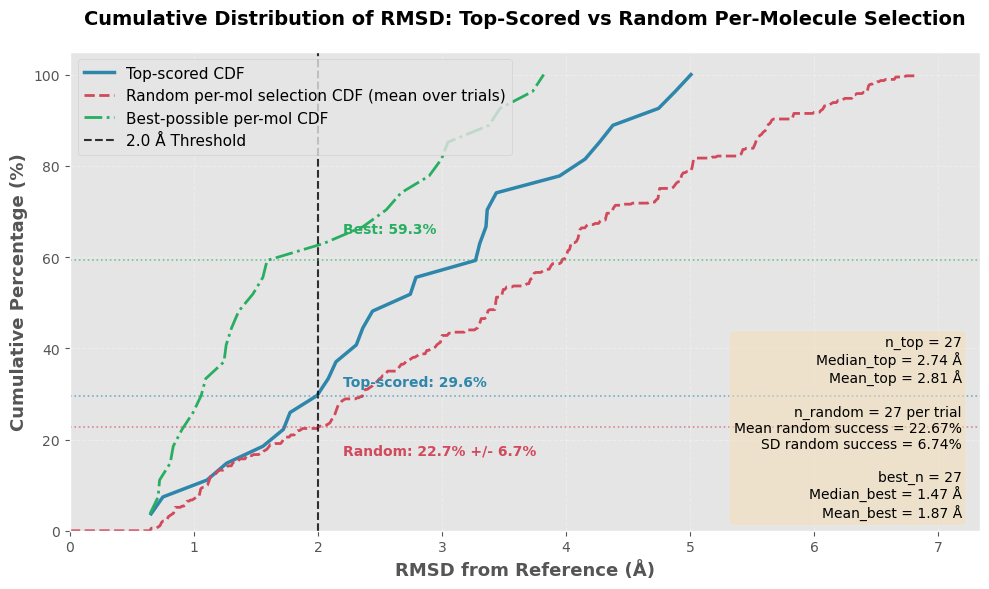

Cumulative distribution statistics (Top-scored):
  7.4% of top-scored molecules have RMSD < 1.0 Å
  14.8% of top-scored molecules have RMSD < 1.5 Å
  29.6% of top-scored molecules have RMSD < 2.0 Å
  48.1% of top-scored molecules have RMSD < 2.5 Å
  55.6% of top-scored molecules have RMSD < 3.0 Å

Cumulative distribution statistics (Random per-mol selection):
  Mean 7.0% +/- 4.1% have RMSD < 1.0 Å
  Mean 16.7% +/- 5.8% have RMSD < 1.5 Å
  Mean 22.7% +/- 6.7% have RMSD < 2.0 Å
  Mean 33.5% +/- 7.6% have RMSD < 2.5 Å
  Mean 42.8% +/- 7.2% have RMSD < 3.0 Å

Cumulative distribution statistics (Best-possible per-mol selection):
  25.9% of best-possible selections have RMSD < 1.0 Å
  51.9% of best-possible selections have RMSD < 1.5 Å
  59.3% of best-possible selections have RMSD < 2.0 Å
  66.7% of best-possible selections have RMSD < 2.5 Å
  81.5% of best-possible selections have RMSD < 3.0 Å


In [18]:
# Prepare data for cumulative distribution (top-scored conformations)
rmsd_values = best_conformations['rmsd'].dropna().sort_values().values
if len(rmsd_values) == 0:
    raise ValueError("No valid top-scored RMSD values available for CDF analysis")
cumulative_pct = np.arange(1, len(rmsd_values) + 1) / len(rmsd_values) * 100

# Compute CDF for random per-molecule selection
np.random.seed(42)
per_mol_rmsds = {}
for mol, grp in abfe_df.groupby('mol_id'):
    vals = grp['rmsd'].dropna().values
    if len(vals) == 0:
        raise ValueError(f"No valid RMSD values for molecule {mol}; random baseline cannot be computed")
    per_mol_rmsds[mol] = vals

n_molecules = len(per_mol_rmsds)
if n_molecules == 0:
    raise ValueError("No per-molecule RMSD data available for random selection CDF")

N_TRIALS = 10_000
mol_keys = sorted(per_mol_rmsds.keys())
sampled_rmsds = np.empty((N_TRIALS, n_molecules), dtype=float)
for t in range(N_TRIALS):
    sampled_rmsds[t, :] = [np.random.choice(per_mol_rmsds[m]) for m in mol_keys]

# Average CDF on a fixed RMSD grid across trials
max_observed_rmsd = max(rmsd_values.max(), sampled_rmsds.max())
x_grid = np.linspace(0, max_observed_rmsd, 500)
trial_cdfs = np.array([
    np.searchsorted(np.sort(trial_rmsds), x_grid, side='right') / len(trial_rmsds) * 100
    for trial_rmsds in sampled_rmsds
])
sampled_cum_pct = trial_cdfs.mean(axis=0)

# Trial-level random success percentages at threshold
random_success_rates = (sampled_rmsds <= RMSD_THRESHOLD).sum(axis=1) / n_molecules * 100
random_success_mean = random_success_rates.mean()
random_success_std = random_success_rates.std(ddof=1)

# Compute best-possible per-molecule CDF (choose lowest RMSD available per molecule)
best_per_mol = np.array([vals.min() for vals in per_mol_rmsds.values()])
best_sorted = np.sort(best_per_mol)
best_cum_pct = np.arange(1, len(best_sorted) + 1) / len(best_sorted) * 100

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))

# Plot cumulative distribution for top-scored
ax.plot(rmsd_values, cumulative_pct, linewidth=2.5, color='#2E86AB', label='Top-scored CDF')

# Plot random-selection average CDF
ax.plot(x_grid, sampled_cum_pct, linewidth=2.0, color='#D1495B', linestyle='--', label='Random per-mol selection CDF (mean over trials)')

# Plot best-possible per-molecule CDF
ax.plot(best_sorted, best_cum_pct, linewidth=2.0, color='#27AE60', linestyle='-.', label='Best-possible per-mol CDF')

# Add reference line at RMSD threshold
ax.axvline(x=RMSD_THRESHOLD, color='black', linestyle='--', linewidth=1.5,
           label=f'{RMSD_THRESHOLD} Å Threshold', alpha=0.8)

# Add horizontal line at success rate for top-scored
success_pct_at_threshold = (rmsd_values <= RMSD_THRESHOLD).sum() / len(rmsd_values) * 100
ax.axhline(y=success_pct_at_threshold, color='#2E86AB', linestyle=':', linewidth=1.2, alpha=0.6)
ax.text(RMSD_THRESHOLD + 0.2, success_pct_at_threshold + 2,
        f'Top-scored: {success_pct_at_threshold:.1f}%', color='#2E86AB', fontweight='bold')

# Add horizontal line for random-selection mean success
ax.axhline(y=random_success_mean, color='#D1495B', linestyle=':', linewidth=1.2, alpha=0.6)
ax.text(RMSD_THRESHOLD + 0.2, random_success_mean - 6,
        f'Random: {random_success_mean:.1f}% +/- {random_success_std:.1f}%', color='#D1495B', fontweight='bold')

# Add horizontal line for best-possible success
best_success_pct = (best_sorted <= RMSD_THRESHOLD).sum() / len(best_sorted) * 100
ax.axhline(y=best_success_pct, color='#27AE60', linestyle=':', linewidth=1.2, alpha=0.6)
ax.text(RMSD_THRESHOLD + 0.2, best_success_pct + 6,
        f'Best: {best_success_pct:.1f}%', color='#27AE60', fontweight='bold')

# Labels and formatting
ax.set_xlabel('RMSD from Reference (Å)', fontsize=13, fontweight='bold')
ax.set_ylabel('Cumulative Percentage (%)', fontsize=13, fontweight='bold')
ax.set_title('Cumulative Distribution of RMSD: Top-Scored vs Random Per-Molecule Selection',
             fontsize=14, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(fontsize=11, loc='upper left')

# Set axis limits
max_x = min(max(max_observed_rmsd, best_sorted.max()) + 0.5, 10)
ax.set_xlim(0, max_x)
ax.set_ylim(0, 105)

# Add statistics box
stats_text = f'n_top = {len(rmsd_values)}\nMedian_top = {np.median(rmsd_values):.2f} Å\nMean_top = {np.mean(rmsd_values):.2f} Å'
stats_text += f"\n\nn_random = {n_molecules} per trial\nMean random success = {random_success_mean:.2f}%\nSD random success = {random_success_std:.2f}%"
stats_text += f"\n\nbest_n = {len(best_sorted)}\nMedian_best = {np.median(best_sorted):.2f} Å\nMean_best = {np.mean(best_sorted):.2f} Å"
ax.text(0.98, 0.02, stats_text, transform=ax.transAxes,
        fontsize=10, verticalalignment='bottom', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

# Print cumulative distribution statistics
print(f"Cumulative distribution statistics (Top-scored):")
for threshold in [1.0, 1.5, 2.0, 2.5, 3.0]:
    pct = (rmsd_values <= threshold).sum() / len(rmsd_values) * 100
    print(f"  {pct:.1f}% of top-scored molecules have RMSD < {threshold} Å")

print(f"\nCumulative distribution statistics (Random per-mol selection):")
for threshold in [1.0, 1.5, 2.0, 2.5, 3.0]:
    trial_pct = (sampled_rmsds <= threshold).sum(axis=1) / n_molecules * 100
    print(f"  Mean {trial_pct.mean():.1f}% +/- {trial_pct.std(ddof=1):.1f}% have RMSD < {threshold} Å")

print(f"\nCumulative distribution statistics (Best-possible per-mol selection):")
for threshold in [1.0, 1.5, 2.0, 2.5, 3.0]:
    pct = (best_sorted <= threshold).sum() / len(best_sorted) * 100
    print(f"  {pct:.1f}% of best-possible selections have RMSD < {threshold} Å")

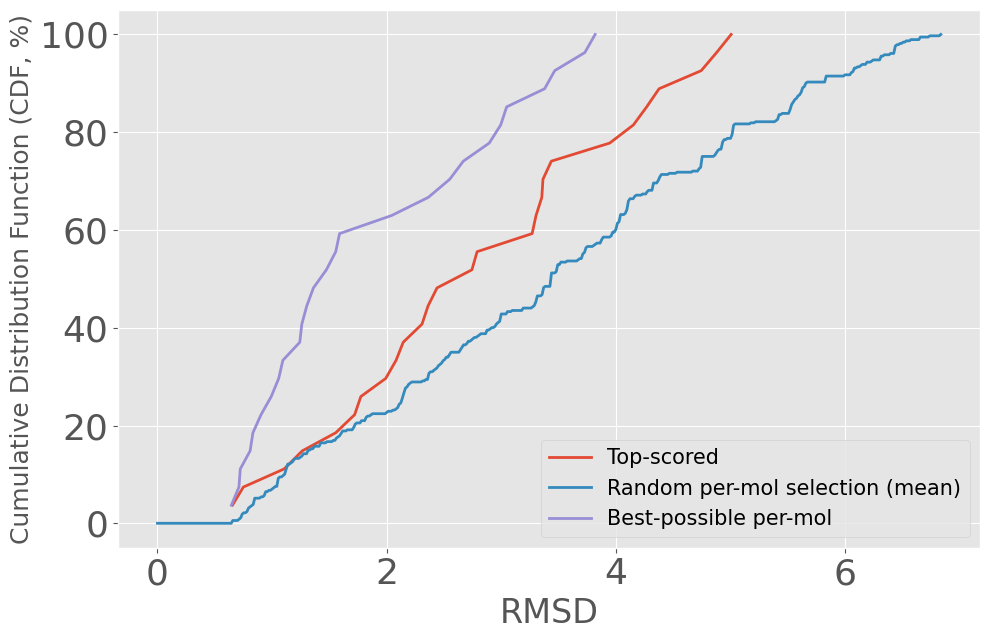

In [19]:
# Consistent style with rest of paper
plt.figure(figsize=(10, 6.5))

plt.plot(rmsd_values, cumulative_pct, label="Top-scored", lw=2)
plt.plot(x_grid, sampled_cum_pct, label="Random per-mol selection (mean)", lw=2)
plt.plot(best_sorted, best_cum_pct, label="Best-possible per-mol", lw=2)

plt.xlabel("RMSD", fontsize=24)
plt.ylabel("Cumulative Distribution Function (CDF, %)", fontsize=18)
plt.tick_params(axis="both", which="major", labelsize=26)
plt.legend(fontsize=15, frameon=True, loc="best")
plt.grid(True)
plt.tight_layout()
plt.savefig("rmsd_cdf_plot.png", dpi=300)

In [20]:
# Paired bootstrap test: top-scored vs random per-molecule selection at 2.0 A
import numpy as np

RMSD_THRESHOLD = 2.0
N_BOOT = 10_000
RNG_SEED = 42

per_mol_rmsds = {
    mol: grp["rmsd"].dropna().to_numpy()
    for mol, grp in abfe_df.groupby("mol_id")
}
if not per_mol_rmsds:
    raise ValueError("No per-molecule RMSD data available for random baseline")
if any(len(vals) == 0 for vals in per_mol_rmsds.values()):
    raise ValueError("One or more molecules have no valid RMSD values")

mol_ids = sorted(per_mol_rmsds.keys(), key=lambda x: int(x.replace("mol", "")))
observed_success = []
for mol_id in mol_ids:
    rmsd_vals = best_conformations.loc[
        best_conformations["mol_id"] == mol_id, "rmsd"
    ].to_numpy()
    if rmsd_vals.size != 1:
        raise ValueError(f"Expected 1 top-scored RMSD for {mol_id}, found {rmsd_vals.size}")
    observed_success.append(float(rmsd_vals[0] <= RMSD_THRESHOLD))
observed_success = np.array(observed_success, dtype=float)

rng = np.random.default_rng(RNG_SEED)
n_molecules = len(mol_ids)
diffs = np.empty(N_BOOT, dtype=float)
for b in range(N_BOOT):
    idx = rng.integers(0, n_molecules, n_molecules)
    obs = observed_success[idx].mean()
    rand = np.mean([rng.choice(per_mol_rmsds[mol_ids[i]]) <= RMSD_THRESHOLD for i in idx])
    diffs[b] = obs - rand

p_one_sided = float(np.mean(diffs <= 0.0))
observed_rate = float(observed_success.mean())
random_rate = float(observed_rate - diffs.mean())

print("Paired bootstrap test at 2.0 A threshold")
print("=" * 55)
print(f"Observed success rate: {observed_rate * 100:.2f}%")
print(f"Random baseline (bootstrap mean): {random_rate * 100:.2f}%")
print(f"Mean difference (obs - random): {diffs.mean() * 100:.2f}%")
print(f"One-sided p-value (obs <= random): {p_one_sided:.4f}")

Paired bootstrap test at 2.0 A threshold
Observed success rate: 29.63%
Random baseline (bootstrap mean): 22.88%
Mean difference (obs - random): 6.75%
One-sided p-value (obs <= random): 0.3128


## 9. Additional Visualizations

Explore the relationship between ABFE scores and RMSD values.

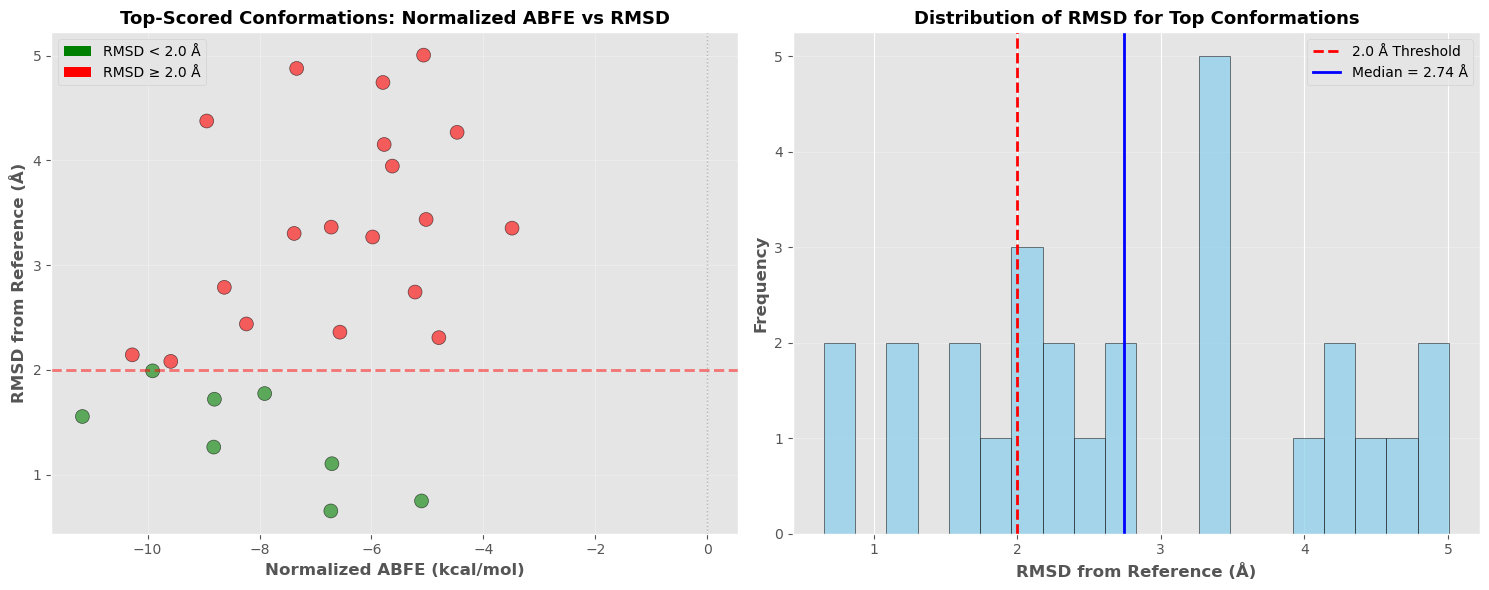

In [21]:
# Scatter plot: ABFE score vs RMSD for top conformations
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: dG vs RMSD for top conformations (using normalized ABFE)
valid_data = best_conformations.dropna(subset=['rmsd', 'mean_dg_normalized'])
colors = ['green' if rmsd < RMSD_THRESHOLD else 'red' for rmsd in valid_data['rmsd']]

ax1.scatter(valid_data['mean_dg_normalized'], valid_data['rmsd'], 
           c=colors, alpha=0.6, s=100, edgecolors='black', linewidth=0.5)
ax1.axhline(y=RMSD_THRESHOLD, color='red', linestyle='--', linewidth=2, alpha=0.5)
ax1.axvline(x=0, color='gray', linestyle=':', linewidth=1, alpha=0.5)
ax1.set_xlabel('Normalized ABFE (kcal/mol)', fontsize=12, fontweight='bold')
ax1.set_ylabel('RMSD from Reference (Å)', fontsize=12, fontweight='bold')
ax1.set_title('Top-Scored Conformations: Normalized ABFE vs RMSD', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='green', label=f'RMSD < {RMSD_THRESHOLD} Å'),
                   Patch(facecolor='red', label=f'RMSD ≥ {RMSD_THRESHOLD} Å')]
ax1.legend(handles=legend_elements, fontsize=10)

# Plot 2: Histogram of RMSD values
ax2.hist(valid_data['rmsd'], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
ax2.axvline(x=RMSD_THRESHOLD, color='red', linestyle='--', linewidth=2, 
           label=f'{RMSD_THRESHOLD} Å Threshold')
ax2.axvline(x=valid_data['rmsd'].median(), color='blue', linestyle='-', linewidth=2,
           label=f'Median = {valid_data["rmsd"].median():.2f} Å')
ax2.set_xlabel('RMSD from Reference (Å)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax2.set_title('Distribution of RMSD for Top Conformations', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### 9.1 All Conformations Analysis

Analyze the relationship between ABFE scores and RMSD for all conformations (not just top-scored).

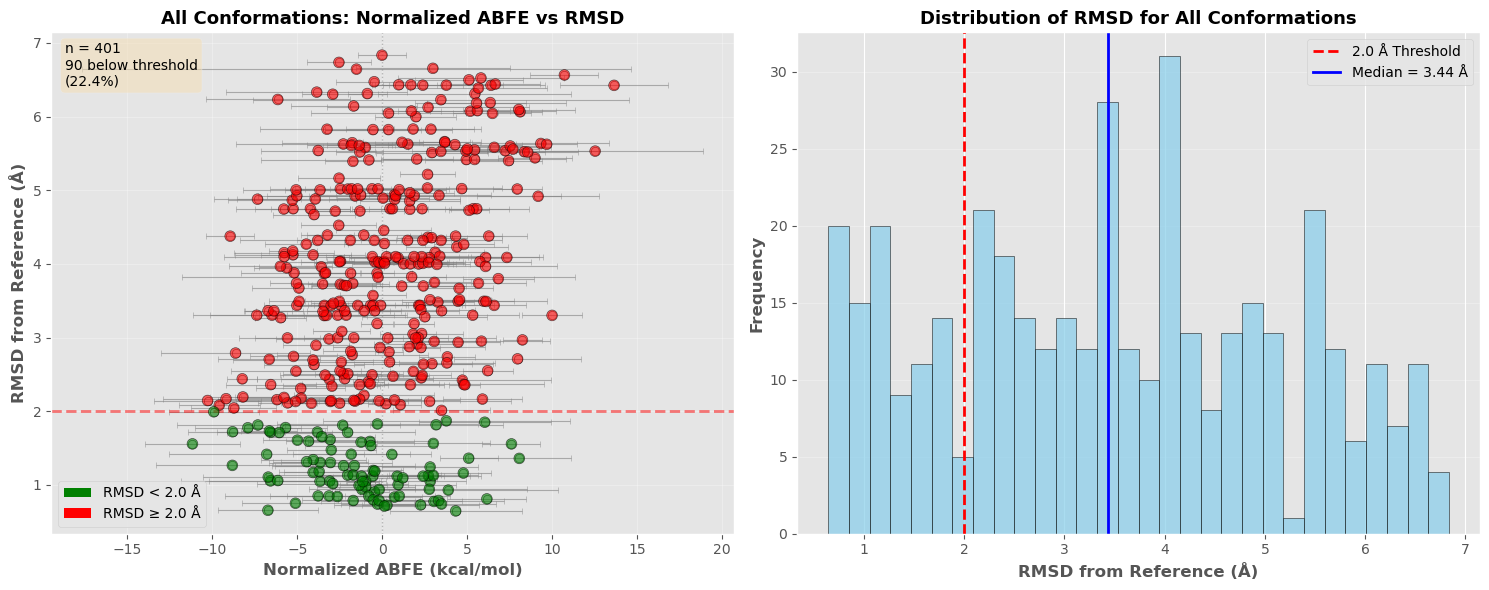

Comparison: All Conformations vs Top-Scored Only
All conformations:
  Total: 401
  Mean RMSD: 3.46 Å
  Median RMSD: 3.44 Å
  Success rate: 22.4%

Top-scored conformations only:
  Total (valid RMSD): 27
  Mean RMSD: 2.81 Å
  Median RMSD: 2.74 Å
  Success rate: 29.6%


In [22]:
# Scatter plot: ABFE score vs RMSD for ALL conformations
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: dG vs RMSD for all conformations (using normalized ABFE)
all_valid_data = abfe_df.dropna(subset=['rmsd', 'mean_dg_normalized'])
if len(all_valid_data) == 0:
    raise ValueError("No valid rows with both RMSD and normalized ABFE")

colors_all = ['green' if rmsd < RMSD_THRESHOLD else 'red' for rmsd in all_valid_data['rmsd']]

# Plot with error bars
ax1.errorbar(all_valid_data['mean_dg_normalized'], all_valid_data['rmsd'],
            xerr=all_valid_data['error'], fmt='o', markersize=6,
            ecolor='gray', elinewidth=0.8, capsize=2, capthick=0.8,
            alpha=0.6, color='none', markeredgewidth=0.5, markeredgecolor='black')

# Color the markers
ax1.scatter(all_valid_data['mean_dg_normalized'], all_valid_data['rmsd'],
           c=colors_all, alpha=0.6, s=60, edgecolors='black', linewidth=0.5, zorder=3)

ax1.axhline(y=RMSD_THRESHOLD, color='red', linestyle='--', linewidth=2, alpha=0.5)
ax1.axvline(x=0, color='gray', linestyle=':', linewidth=1, alpha=0.5)
ax1.set_xlabel('Normalized ABFE (kcal/mol)', fontsize=12, fontweight='bold')
ax1.set_ylabel('RMSD from Reference (Å)', fontsize=12, fontweight='bold')
ax1.set_title('All Conformations: Normalized ABFE vs RMSD', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='green', label=f'RMSD < {RMSD_THRESHOLD} Å'),
                   Patch(facecolor='red', label=f'RMSD ≥ {RMSD_THRESHOLD} Å')]
ax1.legend(handles=legend_elements, fontsize=10)

# Add statistics text
n_success_all = (all_valid_data['rmsd'] < RMSD_THRESHOLD).sum()
success_rate_all = n_success_all / len(all_valid_data) * 100
stats_text = f'n = {len(all_valid_data)}\n{n_success_all} below threshold\n({success_rate_all:.1f}%)'
ax1.text(0.02, 0.98, stats_text, transform=ax1.transAxes,
        fontsize=10, verticalalignment='top', horizontalalignment='left',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Plot 2: Histogram of RMSD values for all conformations
ax2.hist(all_valid_data['rmsd'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
ax2.axvline(x=RMSD_THRESHOLD, color='red', linestyle='--', linewidth=2,
           label=f'{RMSD_THRESHOLD} Å Threshold')
ax2.axvline(x=all_valid_data['rmsd'].median(), color='blue', linestyle='-', linewidth=2,
           label=f'Median = {all_valid_data["rmsd"].median():.2f} Å')
ax2.set_xlabel('RMSD from Reference (Å)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax2.set_title('Distribution of RMSD for All Conformations', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print statistics comparison
print(f"Comparison: All Conformations vs Top-Scored Only")
print(f"="*60)
print(f"All conformations:")
print(f"  Total: {len(all_valid_data)}")
print(f"  Mean RMSD: {all_valid_data['rmsd'].mean():.2f} Å")
print(f"  Median RMSD: {all_valid_data['rmsd'].median():.2f} Å")
print(f"  Success rate: {success_rate_all:.1f}%")

valid_top = best_conformations.dropna(subset=['rmsd'])
if len(valid_top) == 0:
    raise ValueError("No valid RMSD values in best_conformations")

top_success_rate = (valid_top['rmsd'] < RMSD_THRESHOLD).sum() / len(valid_top) * 100
print(f"\nTop-scored conformations only:")
print(f"  Total (valid RMSD): {len(valid_top)}")
print(f"  Mean RMSD: {valid_top['rmsd'].mean():.2f} Å")
print(f"  Median RMSD: {valid_top['rmsd'].median():.2f} Å")
print(f"  Success rate: {top_success_rate:.1f}%")

In [23]:
from openff.toolkit import Molecule

def visualise(df: pd.DataFrame, mol_id: str, receptor_id: str) -> Molecule:
    filtered_df = df[(df['mol_id'] == mol_id) & (df['receptor_id'] == receptor_id)]
    sdf_path = filtered_df["ligand_sdf_path"].values[0]
    print(sdf_path)
    molecule = Molecule.from_file(sdf_path)
    return molecule


if RAW_DATA_AVAILABLE:
    visualise(all_valid_data, "mol3", "rec_final_20")
else:
    print("Skipping visualise() (requires raw ligand SDF files).")

Skipping visualise() (requires raw ligand SDF files).


In [24]:
if RAW_DATA_AVAILABLE:
    visualise(all_valid_data, "mol3", "rec_final_7")
else:
    print("Skipping visualise() (requires raw ligand SDF files).")

Skipping visualise() (requires raw ligand SDF files).


In [25]:
all_valid_data.sort_values('mean_dg', inplace=True)
all_valid_data

,mol_id,receptor_id,mean_dg,error,stats_path,ligand_sdf_path,mol_dir,rec_dir,rmsd,mean_dg_normalized,equil_rmsd_heavy,equil_ref_rmsd,equil_reason
195,mol30,rec_final_20,-27.422,4.475,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,1.263781,-8.818786,1.062028,1.269283,NaN
30,mol13,rec_final_19,-25.721,4.363,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,2.789005,-8.629600,1.218813,2.222947,NaN
281,mol39,rec_final_20,-25.549,2.802,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,1.555697,-11.165625,1.462333,2.195479,NaN
196,mol30,rec_final_19,-25.252,3.009,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,2.703172,-6.648786,1.233587,2.657717,NaN
343,mol44,rec_final_19,-24.999,3.124,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,2.144387,-10.273929,0.844414,1.987192,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
58,mol16,rec_final_2,-3.390,3.568,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,3.490439,6.111333,3.762957,5.602038,NaN
385,mol7,rec_final_2,-2.529,2.798,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,3.738828,5.657267,2.609089,3.000093,NaN
356,mol44,rec_final_18,-2.205,6.344,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,5.531495,12.520071,1.209637,5.032817,NaN
386,mol7,rec_final_12,-2.114,4.222,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,3.965821,6.072267,3.380012,6.473537,NaN


## 10. Per-Molecule Analysis

Examine ABFE scores and RMSD values across different receptor conformations for each molecule.

In [26]:
# Show detailed analysis for each molecule
print("Per-Molecule Summary:")
print("="*90)

for mol_id in sorted(abfe_df['mol_id'].unique()):
    mol_data = abfe_df[abfe_df['mol_id'] == mol_id].copy()
    
    # Get best entry
    best_idx = mol_data['mean_dg'].idxmin()
    best_entry = mol_data.loc[best_idx]
    
    print(f"\n{mol_id}:")
    print(f"  Number of receptor conformations tested: {len(mol_data)}")
    print(f"  Best receptor: {best_entry['receptor_id']}")
    print(f"  Best ABFE: {best_entry['mean_dg']:.2f} ± {best_entry['error']:.2f} kcal/mol")
    print(f"  RMSD at best ABFE: {best_entry['rmsd']:.2f} Å")
    print(f"  Success: {'✓' if best_entry['rmsd'] < RMSD_THRESHOLD else '✗'}")
    
    # Show range of dG and RMSD
    print(f"  dG range: {mol_data['mean_dg'].min():.2f} to {mol_data['mean_dg'].max():.2f} kcal/mol")
    print(f"  RMSD range: {mol_data['rmsd'].min():.2f} to {mol_data['rmsd'].max():.2f} Å")
    
    # Best RMSD in any conformation
    best_rmsd_idx = mol_data['rmsd'].idxmin()
    best_rmsd_entry = mol_data.loc[best_rmsd_idx]
    if best_rmsd_idx != best_idx:
        print(f"  (Best RMSD {best_rmsd_entry['rmsd']:.2f} Å found in {best_rmsd_entry['receptor_id']} with dG={best_rmsd_entry['mean_dg']:.2f})")

print("\n" + "="*90)

Per-Molecule Summary:

mol11:
  Number of receptor conformations tested: 15
  Best receptor: rec_final_9
  Best ABFE: -15.96 ± 1.91 kcal/mol
  RMSD at best ABFE: 3.44 Å
  Success: ✗
  dG range: -15.96 to -4.36 kcal/mol
  RMSD range: 3.38 to 4.23 Å
  (Best RMSD 3.38 Å found in rec_final_6 with dG=-8.67)

mol12:
  Number of receptor conformations tested: 15
  Best receptor: rec_final_19
  Best ABFE: -16.98 ± 1.51 kcal/mol
  RMSD at best ABFE: 3.27 Å
  Success: ✗
  dG range: -16.98 to -4.74 kcal/mol
  RMSD range: 3.05 to 4.39 Å
  (Best RMSD 3.05 Å found in rec_final_15 with dG=-9.19)

mol13:
  Number of receptor conformations tested: 15
  Best receptor: rec_final_19
  Best ABFE: -25.72 ± 4.36 kcal/mol
  RMSD at best ABFE: 2.79 Å
  Success: ✗
  dG range: -25.72 to -3.46 kcal/mol
  RMSD range: 1.26 to 6.43 Å
  (Best RMSD 1.26 Å found in rec_final_16 with dG=-19.37)

mol16:
  Number of receptor conformations tested: 15
  Best receptor: rec_final_6
  Best ABFE: -16.88 ± 2.75 kcal/mol
  RMSD a

In [27]:
from tqdm import tqdm


def compute_fraction_best_ligands_from_rankings(y_true, y_pred, fraction=0.5):
    """
    Compute fraction-best-ligands using rank overlap.

    Parameters
    ----------
    y_true : array-like
        True values where lower is better (RMSD here).
    y_pred : array-like
        Predicted values where lower is better (ABFE here; more negative is better).
    fraction : float
        Fraction of ligands to evaluate.

    Returns
    -------
    float
        Average overlap coefficient from k=1..floor(n*fraction).
    """
    if not (0 <= fraction <= 1):
        raise ValueError("Fraction must be between 0 and 1.")

    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    if y_true.shape != y_pred.shape:
        raise ValueError("y_true and y_pred must have the same shape")
    if y_true.ndim != 1:
        raise ValueError("y_true and y_pred must be 1D arrays")
    if len(y_true) == 0:
        raise ValueError("Cannot compute metric on empty arrays")

    valid = np.isfinite(y_true) & np.isfinite(y_pred)
    if not np.all(valid):
        raise ValueError("y_true and y_pred must contain only finite values")

    n = len(y_true)
    num_best = round(np.floor(n * fraction))
    if num_best < 1:
        raise ValueError(f"fraction={fraction} yields zero top-ranked entries for n={n}")

    true_ranked = np.argsort(y_true)  # lower RMSD is better
    pred_ranked = np.argsort(y_pred)  # lower ABFE (more negative) is better

    overlap_coefficients = []
    for k in range(1, num_best + 1):
        top_true = set(true_ranked[:k])
        top_pred = set(pred_ranked[:k])
        overlap = len(top_true.intersection(top_pred)) / k
        overlap_coefficients.append(overlap)

    return float(np.mean(overlap_coefficients))


def compute_fraction_best_per_mol(df, fraction, y_pred_col="mean_dg", rng=None, shuffle=False):
    """Compute fraction-best per molecule, optionally shuffling predictions."""
    rng = rng or np.random.default_rng(42)
    per_mol = []
    for mol_id in sorted(df["mol_id"].unique(), key=lambda x: int(x.replace("mol", ""))):
        mol_data = df[df["mol_id"] == mol_id].dropna(subset=["rmsd", y_pred_col]).copy()
        if len(mol_data) < 2:
            raise ValueError(
            f"Need at least 2 conformations with finite RMSD and {y_pred_col} for {mol_id}; found {len(mol_data)}"
            )
        y_true = mol_data["rmsd"].to_numpy()
        y_pred = mol_data[y_pred_col].to_numpy()
        if shuffle:
            y_pred = rng.permutation(y_pred)
        fb = compute_fraction_best_ligands_from_rankings(
            y_true=y_true,
            y_pred=y_pred,
            fraction=fraction,
        )
        per_mol.append({
            "mol_id": mol_id,
            "n_conformations": len(mol_data),
            "fraction_best": fb,
        })
    return pd.DataFrame(per_mol).sort_values("mol_id").reset_index(drop=True)


def paired_bootstrap_random_vs_observed(df, fraction, n_boot=10_000, seed=42, show_progress=True):
    """Paired bootstrap: observed vs per-molecule randomized rankings."""
    rng = np.random.default_rng(seed)
    observed_df = compute_fraction_best_per_mol(df, fraction)
    mol_ids = observed_df["mol_id"].to_list()
    observed_vals = observed_df["fraction_best"].to_numpy()
    n_mols = len(mol_ids)
    diffs = np.empty(n_boot, dtype=float)
    iterator = tqdm(range(n_boot), desc="Bootstrapping", unit="iter") if show_progress else range(n_boot)
    for b in iterator:
        idx = rng.integers(0, n_mols, n_mols)
        obs = observed_vals[idx].mean()
        rand_vals = []
        for i in idx:
            mol_id = mol_ids[i]
            mol_data = df[df["mol_id"] == mol_id].dropna(subset=["rmsd", "mean_dg"]).copy()
            y_true = mol_data["rmsd"].to_numpy()
            y_pred = rng.permutation(mol_data["mean_dg"].to_numpy())
            rand_vals.append(
            compute_fraction_best_ligands_from_rankings(y_true, y_pred, fraction)
            )
        rand = float(np.mean(rand_vals))
        diffs[b] = obs - rand
    return observed_vals.mean(), diffs


FRACTION_BEST = 0.5
observed_mean, diffs = paired_bootstrap_random_vs_observed(
    abfe_df,
    FRACTION_BEST,
    n_boot=10_000,
    seed=42,
    show_progress=True,
)
p_one_sided = float(np.mean(diffs <= 0.0))
random_mean = float(observed_mean - diffs.mean())

print("Fraction-Best-Ligand (paired bootstrap vs random rankings)")
print("=" * 70)
print(f"Fraction evaluated: {FRACTION_BEST}")
print(f"Observed mean fraction-best: {observed_mean:.4f}")
print(f"Random baseline (bootstrap mean): {random_mean:.4f}")
print(f"Mean difference (obs - random): {diffs.mean():.4f}")
print(f"One-sided p-value (obs <= random): {p_one_sided:.4f}")

Bootstrapping:   0%|          | 0/10000 [00:00<?, ?iter/s]

Bootstrapping: 100%|██████████| 10000/10000 [03:10<00:00, 52.36iter/s]

Fraction-Best-Ligand (paired bootstrap vs random rankings)
Fraction evaluated: 0.5
Observed mean fraction-best: 0.3107
Random baseline (bootstrap mean): 0.2723
Mean difference (obs - random): 0.0384
One-sided p-value (obs <= random): 0.1426


## 11. Look at the average spread of ABFE scores per molecule and compare this to the intra-compound variance

In [28]:
# Calculate per-molecule statistics
per_mol_stats = []

for mol_id in sorted(abfe_df['mol_id'].unique()):
    mol_data = abfe_df[abfe_df['mol_id'] == mol_id].copy()
    
    # Inter-receptor spread: standard deviation of mean_dg across different receptors
    dg_range = mol_data['mean_dg'].max() - mol_data['mean_dg'].min()
    
    # Average intra-compound uncertainty: mean of the error values
    # Note: errors are 95% Gaussian-based confidence intervals
    # To get standard error: CI_95 ≈ 1.96 * SE, so SE ≈ CI_95 / 1.96
    avg_error = mol_data['error'].mean()
    avg_std_error = avg_error / 1.96  # Convert 95% CI to standard error
    
    per_mol_stats.append({
        'mol_id': mol_id,
        'n_receptors': len(mol_data),
        'dg_range': dg_range,
        'avg_std_error': avg_std_error
    })

per_mol_df = pd.DataFrame(per_mol_stats)

print("\nPer-Molecule Statistics:")
print(per_mol_df.to_string(index=False))

# Print the average range of ABFE scores for each receptor, and the average std deviation for each molecule for a given receptor
avg_dg_range = per_mol_df['dg_range'].mean()
avg_dg_std_error = per_mol_df['avg_std_error'].mean()
print(f"\nAverage ABFE range across receptors per molecule: {avg_dg_range:.2f} kcal/mol")
print(f"Average ABFE standard error of dG results for a given complex: {avg_dg_std_error:.2f} kcal/mol")


Per-Molecule Statistics:
mol_id  n_receptors  dg_range  avg_std_error
 mol11           15    11.605       1.268673
 mol12           15    12.242       1.227993
 mol13           15    22.262       1.721973
 mol16           15    17.369       1.384150
 mol17           16    16.912       1.251881
 mol18           15    11.351       1.120748
 mol20           15    10.797       1.389898
 mol21           13    14.969       1.526570
 mol22           16    11.621       1.043048
 mol25           15    16.260       1.678707
 mol26           15    13.100       1.272449
 mol27           15    14.684       1.656088
  mol3           15    11.052       1.712041
 mol30           14    19.530       1.580357
 mol33           15    11.511       1.352109
 mol34           14    12.528       1.509985
 mol35           15    16.505       1.666599
 mol36           13    11.564       1.240345
 mol37           15    13.008       1.407585
 mol39           16    20.835       1.336862
  mol4           15     9.378

## 11. Export Results

Save the complete analysis results to CSV files for further use.

In [29]:
# Export full results
output_dir = BASE_DIR / "analysis_results"
output_dir.mkdir(parents=True, exist_ok=True)

# Save complete dataframe
full_results_path = output_dir / "abfe_complete_results.csv"
abfe_df[['mol_id', 'receptor_id', 'mean_dg', 'error', 'rmsd']].to_csv(full_results_path, index=False)
print(f"Saved complete results to: {full_results_path}")

# Save best conformations only
best_results_path = output_dir / "abfe_best_conformations.csv"
best_conformations[['mol_id', 'receptor_id', 'mean_dg', 'error', 'rmsd']].to_csv(best_results_path, index=False)
print(f"Saved best conformations to: {best_results_path}")

# Save summary statistics
summary_path = output_dir / "abfe_summary_stats.txt"
with open(summary_path, 'w') as f:
    f.write("ABFE Rescoring Analysis Summary\n")
    f.write("="*60 + "\n\n")
    f.write(f"Total ABFE calculations: {len(abfe_df)}\n")
    f.write(f"Unique molecules: {abfe_df['mol_id'].nunique()}\n")
    f.write(f"Unique receptors: {abfe_df['receptor_id'].nunique()}\n\n")
    f.write(f"RMSD Threshold: {RMSD_THRESHOLD} Å\n")
    f.write(f"Success Rate: {success_rate:.1f}%\n")

    f.write(f"Molecules with RMSD < {RMSD_THRESHOLD} Å: {successful.sum()}/{valid_predictions.sum()}\n\n")
    f.write(f"Mean ABFE (best conformations): {best_conformations['mean_dg'].mean():.2f} kcal/mol\n")
    f.write(f"Mean RMSD (best conformations): {best_conformations['rmsd'].mean():.2f} Å\n")
    f.write(f"Median RMSD (best conformations): {best_conformations['rmsd'].median():.2f} Å\n")

print(f"Saved summary statistics to: {summary_path}")
print("\nAnalysis complete!")

Saved complete results to: /home/campus.ncl.ac.uk/nfc78/research/polaris_retrospective/polaris_plots/analysis_results/abfe_complete_results.csv
Saved best conformations to: /home/campus.ncl.ac.uk/nfc78/research/polaris_retrospective/polaris_plots/analysis_results/abfe_best_conformations.csv
Saved summary statistics to: /home/campus.ncl.ac.uk/nfc78/research/polaris_retrospective/polaris_plots/analysis_results/abfe_summary_stats.txt

Analysis complete!


## 13. RMSD of Equilibrated Pose vs. Input and vs. Reference

How much do the ligand poses shift during system preparation / pre-equilibration, and
do they move *towards* or *away* from the true competition reference?

For each ABFE calculation we load the parameterised, pre-minimisation system
`input/bound_param.rst7` (which preserves the input docked coordinates) and the
pre-equilibrated starting structure `input/bound_preequil.rst7`. The solvated /
pre-equilibrated system is recentred into the simulation box, so before measuring any
ligand RMSD we superimpose the equilibrated complex onto the input complex by protein
C-alpha atoms. After this single alignment we report two quantities:

* **`equil_rmsd_heavy`** — in-place ligand heavy-atom RMSD between the input and
  equilibrated poses (how far the pose moved during preparation).
* **`equil_ref_rmsd`** — symmetry-aware RMSD of the *aligned* equilibrated ligand
  against the competition reference pose (pose accuracy after equilibration).

`bound_param` is in the same coordinate frame as the competition reference: the AMBER
`bound_param` ligand reproduces the SDF-vs-reference `rmsd` exactly, so aligning the
equilibrated complex onto `bound_param` places the equilibrated ligand in the reference
frame. (Skipping this alignment compares poses across different frames and yields
spuriously large RMSDs.)

See the equivalent pose-reading code in the reference submission notebook at
https://github.com/michellab/polaris-poses-challenge-fegrow-a3fe/blob/main/submission/submission.ipynb.


In [30]:
import warnings

import MDAnalysis as mda
from MDAnalysis.analysis import align as mda_align
from rdkit.Geometry import Point3D


def _equil_ligand_to_reference_frame_mol(
    u_eq: mda.Universe,
    ligand_sdf_path: str,
    reference_mol: Chem.Mol,
):
    """Build an RDKit mol holding the equilibrated ligand heavy-atom coordinates,
    ready for a symmetry-aware RMSD against ``reference_mol``.

    ``u_eq`` must already be superimposed onto the input (reference) frame.
    The fegrow SDF supplies the bond graph; we only swap in the equilibrated
    coordinates (verified across all runs to share heavy-atom ordering with the
    AMBER ``LIG`` residue).
    """
    lig_eq_all = u_eq.select_atoms("resname LIG")
    if len(lig_eq_all) == 0:
        raise ValueError("Empty LIG selection")

    heavy_mask = np.array([el != "H" for el in lig_eq_all.elements])
    eq_elements = [el for el, is_heavy in zip(lig_eq_all.elements, heavy_mask) if is_heavy]
    eq_coords = lig_eq_all.positions[heavy_mask]

    lig_noh = Chem.RemoveHs(load_ligand_from_sdf(ligand_sdf_path))
    if lig_noh.GetNumAtoms() != len(eq_coords):
        raise ValueError(
            f"Atom count mismatch: preequil_heavy={len(eq_coords)}, "
            f"ligand_noh={lig_noh.GetNumAtoms()}"
        )
    lig_elements = [a.GetSymbol() for a in lig_noh.GetAtoms()]
    if lig_elements != eq_elements:
        raise ValueError("Element order mismatch between SDF ligand and AMBER LIG")

    conf = Chem.Conformer(lig_noh.GetNumAtoms())
    for i, coord in enumerate(eq_coords):
        conf.SetAtomPosition(i, Point3D(float(coord[0]), float(coord[1]), float(coord[2])))
    lig_noh.RemoveAllConformers()
    lig_noh.AddConformer(conf, assignId=True)
    return lig_noh


def compute_equil_rmsds(
    abfe_run_dir: Path,
    ligand_sdf_path: str,
    reference_mol: Chem.Mol,
) -> dict:
    """Compute, for a single ABFE run, the ligand RMSD between the equilibrated
    pose (``bound_preequil``) and (a) the input docked pose (``bound_param``) and
    (b) the true competition reference pose.

    Both AMBER systems are loaded in their own topology frame. The solvated /
    pre-equilibrated system is recentred into the simulation box, so we first
    superimpose the equilibrated complex onto the input complex by protein
    C-alpha atoms. ``bound_param`` preserves the input docked coordinates, which
    are in the same frame as the competition reference (verified: the AMBER
    ``bound_param`` ligand reproduces the SDF-vs-reference ``rmsd`` exactly).
    After this single alignment:

      * the in-place heavy-atom ligand RMSD measures the input->equilibration
        shift, and
      * the (symmetry-aware) RMSD of the aligned equilibrated ligand against the
        reference measures the pose accuracy after equilibration.
    """
    abfe_run_dir = Path(abfe_run_dir)
    input_dir = abfe_run_dir / "input"

    in_prm = input_dir / "bound_param.prm7"
    in_rst = input_dir / "bound_param.rst7"
    eq_prm = input_dir / "bound_preequil.prm7"
    eq_rst = input_dir / "bound_preequil.rst7"
    for p in (in_prm, in_rst, eq_prm, eq_rst):
        if not p.exists():
            raise FileNotFoundError(f"Missing required AMBER file: {p}")

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        u_in = mda.Universe(str(in_prm), str(in_rst), topology_format="PARM7", format="INPCRD")
        u_eq = mda.Universe(str(eq_prm), str(eq_rst), topology_format="PARM7", format="INPCRD")

        ca_sel = "protein and name CA"
        ca_in = u_in.select_atoms(ca_sel)
        ca_eq = u_eq.select_atoms(ca_sel)
        if len(ca_in) != len(ca_eq) or len(ca_in) == 0:
            raise ValueError(
                f"C-alpha atom count mismatch / empty for {abfe_run_dir}: "
                f"input={len(ca_in)}, equil={len(ca_eq)}"
            )

        # Bring the equilibrated complex into the input (reference) frame.
        mda_align.alignto(u_eq, u_in, select=ca_sel)

        # (a) input -> equilibration ligand shift (shared topology, in-place RMSD)
        lig_in_all = u_in.select_atoms("resname LIG")
        lig_eq_all = u_eq.select_atoms("resname LIG")
        if len(lig_in_all) != len(lig_eq_all) or len(lig_in_all) == 0:
            raise ValueError(
                f"LIG atom count mismatch / empty for {abfe_run_dir}: "
                f"input={len(lig_in_all)}, equil={len(lig_eq_all)}"
            )
        heavy_mask = np.array([el != "H" for el in lig_in_all.elements])
        diff_heavy = (lig_in_all.positions - lig_eq_all.positions)[heavy_mask]
        rmsd_heavy = float(np.sqrt((diff_heavy ** 2).sum(axis=1).mean()))

        # (b) equilibrated pose vs competition reference (now in the same frame)
        lig_eq_mol = _equil_ligand_to_reference_frame_mol(u_eq, ligand_sdf_path, reference_mol)

    ref_noh = Chem.RemoveHs(Chem.Mol(reference_mol))
    pred_spy = spyrmsd.molecule.Molecule.from_rdkit(lig_eq_mol)
    refs_spy = spyrmsd.molecule.Molecule.from_rdkit(ref_noh)
    rmsd_list = spyrmsd.rmsd.rmsdwrapper(refs_spy, pred_spy, symmetry=True, strip=True)
    if len(rmsd_list) != 1:
        raise ValueError(f"Expected 1 RMSD value, got {len(rmsd_list)}")

    return {
        "equil_rmsd_heavy": rmsd_heavy,
        "equil_ref_rmsd": float(rmsd_list[0]),
    }


# Demonstrate on one run (only if the raw AMBER files for it are present).
example_row = abfe_df.iloc[0]
example_dir = Path(example_row["rec_dir"])
if (
    RAW_DATA_AVAILABLE
    and (example_dir / "input" / "bound_preequil.rst7").exists()
    and example_row["mol_id"] in reference_mols
):
    print(f"Example run: {example_dir}")
    print(
        compute_equil_rmsds(
            example_dir,
            example_row["ligand_sdf_path"],
            reference_mols[example_row["mol_id"]],
        )
    )
else:
    print("Skipping compute_equil_rmsds() demo (requires raw AMBER input files).")


Skipping compute_equil_rmsds() demo (requires raw AMBER input files).


/home/campus.ncl.ac.uk/nfc78/miniforge3/envs/a3fe/lib/python3.12/site-packages/Bio/Application/__init__.py:39: BiopythonDeprecationWarning: The Bio.Application modules and modules relying on it have been deprecated.

Due to the on going maintenance burden of keeping command line application
wrappers up to date, we have decided to deprecate and eventually remove these
modules.

We instead now recommend building your command line and invoking it directly
with the subprocess module.
  warnings.warn(


In [31]:
from tqdm.auto import tqdm

# Equilibration RMSDs (equilibrated pose vs input docked pose, and vs competition
# reference). This is the expensive step - it reads the AMBER systems for every run -
# so it is skipped when the columns are already present from the cached dataframe.
_equil_cols = ["equil_rmsd_heavy", "equil_ref_rmsd", "equil_reason"]
_have_equil = (
    {"equil_rmsd_heavy", "equil_ref_rmsd"}.issubset(abfe_df.columns)
    and abfe_df["equil_ref_rmsd"].notna().any()
)

if not FORCE_REBUILD and _have_equil:
    print("Equilibration RMSDs already present (loaded from cache) - skipping recomputation.")
else:
    # Drop any previously-added equilibration columns so this is safe to re-run.
    abfe_df = abfe_df.loc[:, ~abfe_df.columns.isin(_equil_cols)]

    equil_records = []
    for _, row in tqdm(abfe_df.iterrows(), total=len(abfe_df), desc="Equil RMSDs"):
        try:
            rec = compute_equil_rmsds(
                Path(row["rec_dir"]),
                row["ligand_sdf_path"],
                reference_mols[row["mol_id"]],
            )
            rec["equil_reason"] = ""
        except Exception as e:
            print(f"  Failed for {row['mol_id']}/{row['receptor_id']}: {e}")
            rec = {"equil_rmsd_heavy": np.nan, "equil_ref_rmsd": np.nan, "equil_reason": str(e)}
        equil_records.append(rec)

    equil_df = pd.DataFrame(equil_records, index=abfe_df.index)
    abfe_df = pd.concat([abfe_df, equil_df], axis=1)

# Persist the fully-processed dataframe so the notebook is rerunnable without the raw
# ABFE/SDF/AMBER files (it is re-loaded by the collection cell on the next run).
PROCESSED_CACHE.parent.mkdir(parents=True, exist_ok=True)
abfe_df.to_csv(PROCESSED_CACHE, index=False)
print(f"Saved processed dataframe to {PROCESSED_CACHE}")

n_ok = int(abfe_df["equil_rmsd_heavy"].notna().sum())
print("\nEquilibration RMSD statistics (ligand heavy atoms, equilibrated vs input):")
print(f"  N successful : {n_ok} / {len(abfe_df)}")
print(f"  Mean         : {float(abfe_df['equil_rmsd_heavy'].mean()):.3f} A")
print(f"  Median       : {float(abfe_df['equil_rmsd_heavy'].median()):.3f} A")
print(f"  Min          : {float(abfe_df['equil_rmsd_heavy'].min()):.3f} A")
print(f"  Max          : {float(abfe_df['equil_rmsd_heavy'].max()):.3f} A")

n_ref_ok = int(abfe_df["equil_ref_rmsd"].notna().sum())
print("\nEquilibrated-pose RMSD vs competition reference:")
print(f"  N successful : {n_ref_ok} / {len(abfe_df)}")
print(f"  Mean         : {float(abfe_df['equil_ref_rmsd'].mean()):.3f} A")
print(f"  Median       : {float(abfe_df['equil_ref_rmsd'].median()):.3f} A")
print(f"  Min          : {float(abfe_df['equil_ref_rmsd'].min()):.3f} A")
print(f"  Max          : {float(abfe_df['equil_ref_rmsd'].max()):.3f} A")

# Report any failures per molecule
missing = abfe_df["equil_ref_rmsd"].isna()
if missing.any():
    missing_by_mol = (
        abfe_df.assign(_missing=missing)
        .groupby("mol_id")["_missing"]
        .sum()
        .sort_values(ascending=False)
        .astype(int)
    )
    print("\nMissing equilibrated-RMSD rows per molecule:")
    print(missing_by_mol[missing_by_mol > 0].to_string())

abfe_df[[
    "mol_id",
    "receptor_id",
    "mean_dg",
    "rmsd",
    "equil_rmsd_heavy",
    "equil_ref_rmsd",
    "equil_reason",
]].head(10)

Equilibration RMSDs already present (loaded from cache) - skipping recomputation.
Saved processed dataframe to /home/campus.ncl.ac.uk/nfc78/research/polaris_retrospective/polaris_plots/analysis_results/abfe_df_processed.csv

Equilibration RMSD statistics (ligand heavy atoms, equilibrated vs input):
  N successful : 401 / 401
  Mean         : 1.794 A
  Median       : 1.682 A
  Min          : 0.708 A
  Max          : 4.602 A

Equilibrated-pose RMSD vs competition reference:
  N successful : 401 / 401
  Mean         : 3.628 A
  Median       : 3.327 A
  Min          : 0.441 A
  Max          : 7.622 A


,mol_id,receptor_id,mean_dg,rmsd,equil_rmsd_heavy,equil_ref_rmsd,equil_reason
0,mol11,rec_final_9,-15.965,3.436622,1.960371,4.377478,NaN
1,mol11,rec_final_20,-15.013,4.121978,1.691425,3.898685,NaN
2,mol11,rec_final_19,-14.350,3.436383,2.010125,3.541162,NaN
3,mol11,rec_final_16,-13.948,3.436613,1.564896,3.639764,NaN
4,mol11,rec_final_13,-13.370,3.434843,1.017730,3.728062,NaN
5,mol11,rec_final_15,-12.386,3.436551,2.123115,3.838351,NaN
6,mol11,rec_final_4,-11.632,3.435609,1.384005,3.307858,NaN
7,mol11,rec_final_5,-11.478,3.436637,1.715648,3.142355,NaN
8,mol11,rec_final_14,-11.039,3.436443,1.827857,2.795604,NaN
9,mol11,rec_final_11,-8.799,3.436529,2.315375,5.052074,NaN


In [32]:
abfe_df.head()

,mol_id,receptor_id,mean_dg,error,stats_path,ligand_sdf_path,mol_dir,rec_dir,rmsd,mean_dg_normalized,equil_rmsd_heavy,equil_ref_rmsd,equil_reason
0,mol11,rec_final_9,-15.965,1.909,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,3.436622,-5.0236,1.960371,4.377478,NaN
1,mol11,rec_final_20,-15.013,3.051,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,4.121978,-4.0716,1.691425,3.898685,NaN
2,mol11,rec_final_19,-14.350,0.983,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,3.436383,-3.4086,2.010125,3.541162,NaN
3,mol11,rec_final_16,-13.948,0.992,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,3.436613,-3.0066,1.564896,3.639764,NaN
4,mol11,rec_final_13,-13.370,2.424,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,3.434843,-2.4286,1.017730,3.728062,NaN


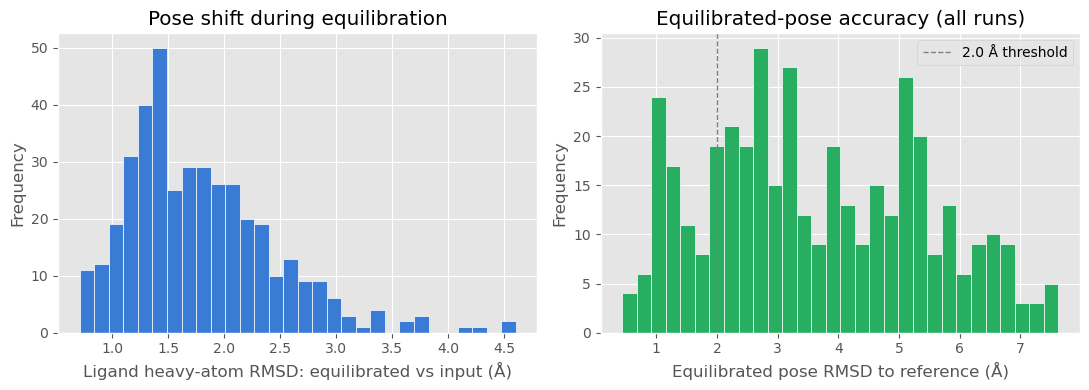

In [33]:
# Distributions of the equilibration-induced ligand shift and of the
# equilibrated-pose accuracy vs the competition reference.
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(abfe_df["equil_rmsd_heavy"].dropna(), bins=30, color="#3a7bd5", edgecolor="white")
axes[0].set_xlabel("Ligand heavy-atom RMSD: equilibrated vs input (Å)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Pose shift during equilibration")

axes[1].hist(abfe_df["equil_ref_rmsd"].dropna(), bins=30, color="#27AE60", edgecolor="white")
axes[1].axvline(RMSD_THRESHOLD, color="grey", linestyle="--", linewidth=1,
                label=f"{RMSD_THRESHOLD} Å threshold")
axes[1].set_xlabel("Equilibrated pose RMSD to reference (Å)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Equilibrated-pose accuracy (all runs)")
axes[1].legend(loc="best")

plt.tight_layout()
plt.show()


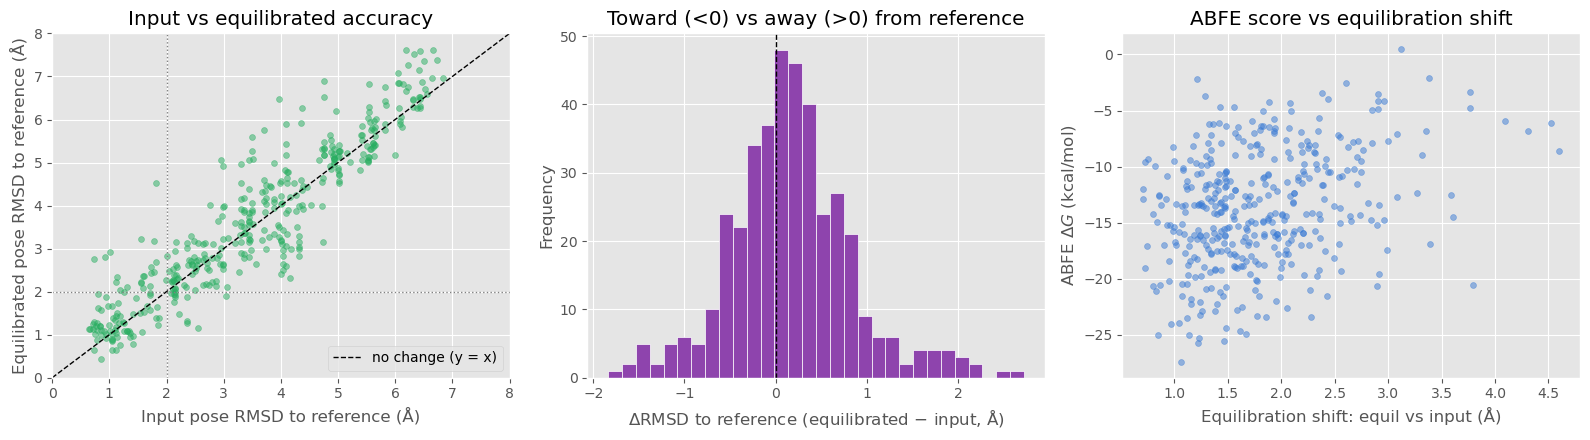

Equilibration moved the ligand TOWARDS the reference in 158/401 runs (39.4%) and AWAY in 243/401 (60.6%).
Mean change in reference RMSD (equil - input): +0.169 Å (median +0.135 Å)

Spearman rho (equil shift vs ABFE dG)        : +0.285  (p=6.59e-09)
Spearman rho (equil shift vs equil-ref RMSD) : +0.327  (p=2.01e-11)


In [34]:
# Does equilibration move poses TOWARDS or AWAY from the true reference, and does
# the equilibration shift correlate with the ABFE score?
from scipy.stats import spearmanr

valid = abfe_df.dropna(subset=["equil_rmsd_heavy", "equil_ref_rmsd", "rmsd", "mean_dg"]).copy()
valid["ref_delta"] = valid["equil_ref_rmsd"] - valid["rmsd"]  # >0 => moved away from reference

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# (1) input-pose RMSD vs equilibrated-pose RMSD (both vs reference), with y = x line.
lim = max(valid["rmsd"].max(), valid["equil_ref_rmsd"].max()) * 1.05
axes[0].scatter(valid["rmsd"], valid["equil_ref_rmsd"], alpha=0.5, s=18, color="#27AE60")
axes[0].plot([0, lim], [0, lim], color="black", linestyle="--", linewidth=1, label="no change (y = x)")
axes[0].axvline(RMSD_THRESHOLD, color="grey", linestyle=":", linewidth=1)
axes[0].axhline(RMSD_THRESHOLD, color="grey", linestyle=":", linewidth=1)
axes[0].set_xlim(0, lim)
axes[0].set_ylim(0, lim)
axes[0].set_xlabel("Input pose RMSD to reference (Å)")
axes[0].set_ylabel("Equilibrated pose RMSD to reference (Å)")
axes[0].set_title("Input vs equilibrated accuracy")
axes[0].legend(loc="best")

# (2) paired change in reference RMSD induced by equilibration.
axes[1].hist(valid["ref_delta"], bins=30, color="#8e44ad", edgecolor="white")
axes[1].axvline(0.0, color="black", linestyle="--", linewidth=1)
axes[1].set_xlabel(r"$\Delta$RMSD to reference (equilibrated $-$ input, Å)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Toward (<0) vs away (>0) from reference")

# (3) equilibration shift vs ABFE score.
axes[2].scatter(valid["equil_rmsd_heavy"], valid["mean_dg"], alpha=0.5, s=18, color="#3a7bd5")
axes[2].set_xlabel("Equilibration shift: equil vs input (Å)")
axes[2].set_ylabel(r"ABFE $\Delta G$ (kcal/mol)")
axes[2].set_title("ABFE score vs equilibration shift")

plt.tight_layout()
plt.show()

n_toward = int((valid["ref_delta"] < 0).sum())
n_away = int((valid["ref_delta"] > 0).sum())
print(f"Equilibration moved the ligand TOWARDS the reference in {n_toward}/{len(valid)} runs "
      f"({n_toward / len(valid) * 100:.1f}%) and AWAY in {n_away}/{len(valid)} "
      f"({n_away / len(valid) * 100:.1f}%).")
print(f"Mean change in reference RMSD (equil - input): {valid['ref_delta'].mean():+.3f} Å "
      f"(median {valid['ref_delta'].median():+.3f} Å)")

rho_dg, p_dg = spearmanr(valid["equil_rmsd_heavy"], valid["mean_dg"])
rho_ref, p_ref = spearmanr(valid["equil_rmsd_heavy"], valid["equil_ref_rmsd"])
print(f"\nSpearman rho (equil shift vs ABFE dG)        : {rho_dg:+.3f}  (p={p_dg:.3g})")
print(f"Spearman rho (equil shift vs equil-ref RMSD) : {rho_ref:+.3f}  (p={p_ref:.3g})")


## 14. Equilibrated-Pose RMSD Analysis

Repeat the top-scored and random-baseline CDF analysis using equilibrated poses as the RMSD reference.

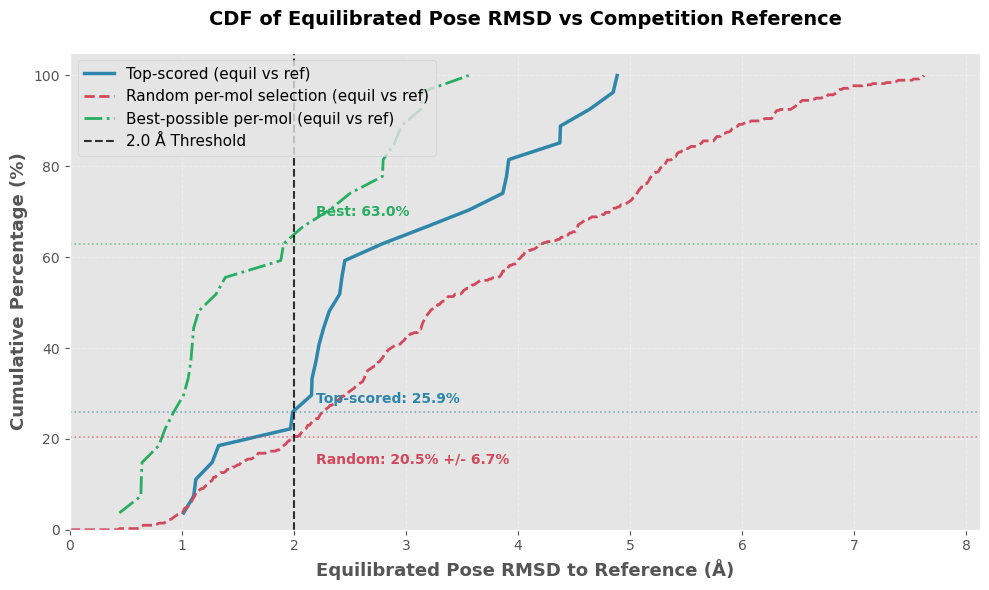

Equilibrated RMSD (vs reference) statistics (Top-scored):
  0.0% of top-scored molecules have equil RMSD < 1.0 Å
  18.5% of top-scored molecules have equil RMSD < 1.5 Å
  25.9% of top-scored molecules have equil RMSD < 2.0 Å
  59.3% of top-scored molecules have equil RMSD < 2.5 Å
  63.0% of top-scored molecules have equil RMSD < 3.0 Å

Equilibrated RMSD (vs reference) statistics (Random per-mol selection):
  Mean 3.9% +/- 3.4% have equil RMSD < 1.0 Å
  Mean 14.3% +/- 5.8% have equil RMSD < 1.5 Å
  Mean 20.5% +/- 6.7% have equil RMSD < 2.0 Å
  Mean 30.4% +/- 7.6% have equil RMSD < 2.5 Å
  Mean 42.1% +/- 8.1% have equil RMSD < 3.0 Å

Equilibrated RMSD (vs reference) statistics (Best-possible per-mol selection):
  25.9% of best-possible selections have equil RMSD < 1.0 Å
  55.6% of best-possible selections have equil RMSD < 1.5 Å
  63.0% of best-possible selections have equil RMSD < 2.0 Å
  70.4% of best-possible selections have equil RMSD < 2.5 Å
  88.9% of best-possible selections have 

In [35]:
# Equilibrated-pose RMSD analysis (equilibrated pose vs competition reference)
equil_col = "equil_ref_rmsd"
best_equil_conformations = abfe_df.loc[abfe_df.groupby("mol_id")["mean_dg"].idxmin()].copy()
if best_equil_conformations[equil_col].isna().any():
    missing = best_equil_conformations[best_equil_conformations[equil_col].isna()]["mol_id"].tolist()
    raise ValueError(f"Missing equilibrated-to-reference RMSD for top-scored: {missing}")
equil_rmsd_values = best_equil_conformations[equil_col].sort_values().values
equil_cumulative_pct = np.arange(1, len(equil_rmsd_values) + 1) / len(equil_rmsd_values) * 100

# Compute CDF for random per-molecule selection (equilibrated vs reference RMSD)
np.random.seed(42)
per_mol_equil_rmsds = {}
for mol, grp in abfe_df.groupby("mol_id"):
    vals = grp[equil_col].values
    if np.isnan(vals).any():
        raise ValueError(f"Missing equilibrated-to-reference RMSD values for molecule {mol}")
    per_mol_equil_rmsds[mol] = vals

n_molecules_equil = len(per_mol_equil_rmsds)
if n_molecules_equil == 0:
    raise ValueError("No per-molecule equilibrated-to-reference RMSD data available for random selection CDF")

N_TRIALS_EQUIL = 10_000
mol_keys_equil = sorted(per_mol_equil_rmsds.keys())
sampled_equil_rmsds = np.empty((N_TRIALS_EQUIL, n_molecules_equil), dtype=float)
for t in range(N_TRIALS_EQUIL):
    sampled_equil_rmsds[t, :] = [np.random.choice(per_mol_equil_rmsds[m]) for m in mol_keys_equil]

# Average CDF on a fixed RMSD grid across trials
max_observed_equil = max(equil_rmsd_values.max(), sampled_equil_rmsds.max())
x_grid_equil = np.linspace(0, max_observed_equil, 500)
trial_cdfs_equil = np.array([
    np.searchsorted(np.sort(trial_rmsds), x_grid_equil, side="right") / len(trial_rmsds) * 100
    for trial_rmsds in sampled_equil_rmsds
])
sampled_equil_cum_pct = trial_cdfs_equil.mean(axis=0)

# Trial-level random success percentages at threshold
random_equil_success_rates = (sampled_equil_rmsds <= RMSD_THRESHOLD).sum(axis=1) / n_molecules_equil * 100
random_equil_success_mean = random_equil_success_rates.mean()
random_equil_success_std = random_equil_success_rates.std(ddof=1)

# Best-possible per-molecule CDF (choose lowest equilibrated RMSD per molecule)
best_equil_per_mol = np.array([vals.min() for vals in per_mol_equil_rmsds.values()])
best_equil_sorted = np.sort(best_equil_per_mol)
best_equil_cum_pct = np.arange(1, len(best_equil_sorted) + 1) / len(best_equil_sorted) * 100

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(equil_rmsd_values, equil_cumulative_pct, linewidth=2.5, color="#2E86AB", label="Top-scored (equil vs ref)")
ax.plot(x_grid_equil, sampled_equil_cum_pct, linewidth=2.0, color="#D1495B", linestyle="--",
        label="Random per-mol selection (equil vs ref)")
ax.plot(best_equil_sorted, best_equil_cum_pct, linewidth=2.0, color="#27AE60", linestyle="-.",
        label="Best-possible per-mol (equil vs ref)")
ax.axvline(x=RMSD_THRESHOLD, color="black", linestyle="--", linewidth=1.5,
           label=f"{RMSD_THRESHOLD} Å Threshold", alpha=0.8)

# Add horizontal line at success rate for top-scored
equil_success_pct = (equil_rmsd_values <= RMSD_THRESHOLD).sum() / len(equil_rmsd_values) * 100
ax.axhline(y=equil_success_pct, color="#2E86AB", linestyle=":", linewidth=1.2, alpha=0.6)
ax.text(RMSD_THRESHOLD + 0.2, equil_success_pct + 2,
        f"Top-scored: {equil_success_pct:.1f}%", color="#2E86AB", fontweight="bold")

# Add horizontal line for random-selection mean success
ax.axhline(y=random_equil_success_mean, color="#D1495B", linestyle=":", linewidth=1.2, alpha=0.6)
ax.text(RMSD_THRESHOLD + 0.2, random_equil_success_mean - 6,
        f"Random: {random_equil_success_mean:.1f}% +/- {random_equil_success_std:.1f}%",
        color="#D1495B", fontweight="bold")

# Add horizontal line for best-possible success
best_equil_success_pct = (best_equil_sorted <= RMSD_THRESHOLD).sum() / len(best_equil_sorted) * 100
ax.axhline(y=best_equil_success_pct, color="#27AE60", linestyle=":", linewidth=1.2, alpha=0.6)
ax.text(RMSD_THRESHOLD + 0.2, best_equil_success_pct + 6,
        f"Best: {best_equil_success_pct:.1f}%", color="#27AE60", fontweight="bold")

# Labels and formatting
ax.set_xlabel("Equilibrated Pose RMSD to Reference (Å)", fontsize=13, fontweight="bold")
ax.set_ylabel("Cumulative Percentage (%)", fontsize=13, fontweight="bold")
ax.set_title("CDF of Equilibrated Pose RMSD vs Competition Reference",
             fontsize=14, fontweight="bold", pad=20)
ax.grid(True, alpha=0.3, linestyle="--")
ax.legend(fontsize=11, loc="upper left")

# Set axis limits
max_x_equil = max(max_observed_equil, best_equil_sorted.max()) + 0.5
ax.set_xlim(0, max_x_equil)
ax.set_ylim(0, 105)

plt.tight_layout()
plt.show()

# Print summary stats
print("Equilibrated RMSD (vs reference) statistics (Top-scored):")
for threshold in [1.0, 1.5, 2.0, 2.5, 3.0]:
    pct = (equil_rmsd_values <= threshold).sum() / len(equil_rmsd_values) * 100
    print(f"  {pct:.1f}% of top-scored molecules have equil RMSD < {threshold} Å")

print("\nEquilibrated RMSD (vs reference) statistics (Random per-mol selection):")
for threshold in [1.0, 1.5, 2.0, 2.5, 3.0]:
    trial_pct = (sampled_equil_rmsds <= threshold).sum(axis=1) / n_molecules_equil * 100
    print(f"  Mean {trial_pct.mean():.1f}% +/- {trial_pct.std(ddof=1):.1f}% have equil RMSD < {threshold} Å")

print("\nEquilibrated RMSD (vs reference) statistics (Best-possible per-mol selection):")
for threshold in [1.0, 1.5, 2.0, 2.5, 3.0]:
    pct = (best_equil_sorted <= threshold).sum() / len(best_equil_sorted) * 100
    print(f"  {pct:.1f}% of best-possible selections have equil RMSD < {threshold} Å")

In [36]:
# Save ligand + protein structures for visual inspection. This reads the raw AMBER
# systems for every run, so it is skipped when the raw data is not available.
if not RAW_DATA_AVAILABLE:
    print("Skipping pose PDB export for visual inspection (requires raw AMBER input files).")
else:
    # Save ligand + protein structures for visual inspection (input and equilibrated poses)
    from pathlib import Path
    import warnings
    from MDAnalysis.analysis import align as mda_align

    vis_root = BASE_DIR / "analysis_results" / "visual_inspection"
    lig_dir = vis_root / "ligand_pdb"
    prot_dir = vis_root / "protein_pdb"
    complex_dir = vis_root / "complex_pdb"
    lig_dir.mkdir(parents=True, exist_ok=True)
    prot_dir.mkdir(parents=True, exist_ok=True)
    complex_dir.mkdir(parents=True, exist_ok=True)

    REF_SELECT = "protein and name CA"

    def _load_reference_universe(tag: str) -> mda.Universe:
        for _, row in abfe_df.iterrows():
            rec_dir = Path(row["rec_dir"])
            input_dir = rec_dir / "input"
            prm = input_dir / f"bound_{tag}.prm7"
            rst = input_dir / f"bound_{tag}.rst7"
            if prm.exists() and rst.exists():
                return mda.Universe(str(prm), str(rst), topology_format="PARM7", format="INPCRD")
        raise FileNotFoundError(f"No reference {tag} files found for alignment")

    # Align everything to a single reference frame so files overlay cleanly in viewers
    ref_u = _load_reference_universe("param")

    def _write_pose_structures(rec_dir: Path, mol_id: str, receptor_id: str, tag: str) -> None:
        input_dir = rec_dir / "input"
        prm = input_dir / f"bound_{tag}.prm7"
        rst = input_dir / f"bound_{tag}.rst7"
        if not (prm.exists() and rst.exists()):
            raise FileNotFoundError(f"Missing {tag} files for {rec_dir}")

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            u = mda.Universe(str(prm), str(rst), topology_format="PARM7", format="INPCRD")

        mda_align.alignto(u, ref_u, select=REF_SELECT)

        protein = u.select_atoms("protein")
        ligand = u.select_atoms("resname LIG")
        if len(protein) == 0 or len(ligand) == 0:
            raise ValueError(f"Empty protein/ligand selection for {rec_dir}")

        base = f"{mol_id}_{receptor_id}_{tag}"
        protein.write(str(prot_dir / f"{base}_protein.pdb"))
        ligand.write(str(lig_dir / f"{base}_ligand.pdb"))
        (protein + ligand).write(str(complex_dir / f"{base}_complex.pdb"))

    n_written = 0
    for _, row in abfe_df.iterrows():
        rec_dir = Path(row["rec_dir"])
        mol_id = row["mol_id"]
        receptor_id = row["receptor_id"]
        try:
            _write_pose_structures(rec_dir, mol_id, receptor_id, "param")
            _write_pose_structures(rec_dir, mol_id, receptor_id, "preequil")
            n_written += 2
        except Exception as e:
            print(f"Skipping {mol_id}/{receptor_id}: {e}")

    print(f"Saved {n_written} ligand+protein pose pairs to: {vis_root}")
    print(f"Complex PDBs saved in: {complex_dir}")

Skipping pose PDB export for visual inspection (requires raw AMBER input files).
